# Parametrized gates and gradients — differentiating a quantum circuit four ways

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Everything so far in these notes has been a *simulation of a fixed physical process*: a Hamiltonian was given, a circuit
was given, and we computed what the state does. This chapter inverts the question. We fix a **family** of circuits
$U(\boldsymbol\theta)$ controlled by a vector of angles $\boldsymbol\theta\in\mathbb R^{n}$, define a number

$$C(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert\,\hat O\,\vert\psi(\boldsymbol\theta)\rangle,
  \qquad \vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\vert 0\rangle^{\otimes N},$$

that says how good the resulting state is, and ask a classical computer to **minimise** it. That is a *variational
quantum algorithm*: a hybrid loop in which a quantum device (or, here, a simulator) evaluates the cost and a classical
optimiser proposes the next angles.

```text
    classical optimiser  --- theta --->  parametrized circuit U(theta)|0..0>
           ^                                        |
           |                                        v
           +------- cost C(theta) <----------  measurement of O
```

**Why people study this.** A fault-tolerant quantum computer running Shor's or the phase-estimation algorithm needs
millions of physical qubits and error correction. The devices that exist now have tens to hundreds of noisy qubits and
circuits that decohere after a few tens of layers. A variational algorithm is designed for exactly that regime: the
quantum part is a *short* circuit, everything expensive and iterative is pushed onto the classical optimiser, and the
free angles can absorb part of the hardware's systematic errors. The first experiment of this kind solved a two-qubit
chemistry problem on a photonic chip (Peruzzo *et al.*, 2014); the framework was formalised shortly afterwards (McClean
*et al.*, 2016) and scaled to six superconducting qubits (Kandala *et al.*, 2017). The same loop is behind the
variational quantum eigensolver, quantum machine learning, and variational state compression.

**What is simulated here.** Nothing in this notebook is a quantum computer: the states are the rank-$N$ tensors of our
einsum engine, and every "measured" expectation value is computed exactly unless we deliberately sample from it. That is
a feature. It lets us ask questions that no experiment can answer — what is the *exact* gradient, how large is the
estimator variance, how flat is the landscape at $N=10$ — and it lets us test the gradient formulas that hardware is
forced to use against the exact answer that only a simulator knows.

**The problem this notebook solves.** Every optimiser in the next notebook needs a gradient
$\partial C/\partial\theta_k$. On a simulator we can simply call `jax.grad`. On hardware that is impossible: there is no
access to the amplitudes, only to measurement statistics. So four different methods are in use, and they differ by orders
of magnitude in accuracy, in the number of circuit executions, and in memory. We derive all four, implement all four,
and measure them against each other.

**Road map.**

1. **Parametrized gates** as exponentials of Pauli operators: single-qubit rotations, two-qubit rotations, controlled
   rotations, and the eigenvalue structure that will decide the gradient rules (Section 3).
2. **Ansätze**: the hardware-efficient ansatz with its parameter count derived, and a problem-inspired
   Hamiltonian-variational ansatz built from a Trotterised adiabatic path (Section 4).
3. **Cost functions**: the energy of a local Hamiltonian, and state-preparation infidelity; global versus local costs
   (Section 5).
4. **The landscape along one angle** is a pure sinusoid $a+b\cos(\theta-c)$ — derived from the two eigenvalues of the
   gate's generator, then measured by fitting a scan (Section 6).
5. **Gradients four ways**: finite differences with the truncation/round-off trade-off and the optimal step (Section 7);
   the parameter-shift rule, derived, plus the four-term rule that controlled rotations need (Section 8); SPSA, with its
   bias and variance derived and measured (Section 9); reverse-mode automatic differentiation, explained as forward
   storage plus backward adjoint gates, with a hand-written adjoint differentiator checked against `jax.grad`
   (Section 10).
6. **Cost comparison** of all four versus the number of parameters: circuit evaluations, wall time, compiled memory
   (Section 11).
7. **Shot noise**: the variance of a parameter-shift gradient estimated from finite samples, and a fair comparison with
   SPSA at equal shot budget (Section 12).
8. **Barren plateaus**: the variance of one gradient component over random angles, measured as a function of $N$ for a
   global and a local cost, with the exponent fitted (Section 13).

### What you will learn

*Physics*

* why a rotation generated by a Pauli operator makes the expectation value of any observable a sinusoid in its angle,
  and what changes when the generator has more than two distinct eigenvalues;
* what an ansatz is, why "hardware-efficient" and "problem-inspired" are opposite design philosophies, and how the
  Hamiltonian-variational ansatz descends from adiabatic evolution;
* why a cost built from a *global* observable becomes exponentially flat with system size while a *local* one need not —
  the barren-plateau phenomenon, measured here rather than quoted.

*Numerical methods*

* the truncation-versus-round-off trade-off of finite differences and the resulting optimal step
  $h_\star\propto\varepsilon_{\text{mach}}^{1/3}$;
* the parameter-shift rule as an *exact* identity, not an approximation, and its four-term generalisation;
* SPSA: unbiasedness to $O(c^2)$, variance $\lVert\nabla C\rVert^2-(\partial_kC)^2$, and why that is a good trade when
  the cost is noisy anyway;
* reverse-mode automatic differentiation on a circuit: one forward pass, one backward pass with adjoint gates, cost
  independent of the number of parameters, and the memory it costs.

*Implementation practice*

* `jax.grad` straight through an einsum simulator, and a hand-written adjoint differentiator that reproduces it;
* `jax.vmap` to batch all $2n$ shifted circuits of a parameter-shift gradient into one call, and to batch hundreds of
  random parameter draws for a variance study;
* honest benchmarking: compile time separated from run time, evaluation counts reported next to wall times, and
  compiled-memory footprints read off the XLA memory analysis.

### Prerequisites

* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): gates as
  unitaries, `apply_gate`, circuits as gate lists, rotations $R_x,R_y,R_z$;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) and
  [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  states as rank-$N$ tensors, expectation values of local operators;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): the Born rule and sampling bit strings, needed
  for the shot-noise section;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as lists of local terms, the exact ground energy from Lanczos;
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `grad`, PRNG keys.

**What comes next.** [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) takes the gradients
built here and feeds them to gradient descent, momentum, Adam, SPSA and the quantum natural gradient, with `lax.scan`
training loops and statistics over random initialisations;
[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb)
then runs the full algorithm on spin chains and compares the optimised state with the exact ground state.

**Conventions and sizes.** Qubit $q$ is tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; Hamiltonians are
written in the Pauli convention $H=\sum J\,ZZ+\sum h\,X$. All states are pure state vectors, so we can afford
$N\le10$ everywhere and $N=10$ in the barren-plateau scan.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

We need the rotation gates and the two-qubit Pauli rotations, `apply_gate`, the hardware-efficient ansatz with its
parameter count, the Hamiltonian machinery (`heisenberg_terms`, `energy`, `dense_hamiltonian`, `lanczos_ground_state`),
`sample_bitstrings` for the shot-noise section, and — as the reference implementations we must reproduce and then
outperform — the engine's `parameter_shift_grad` and `spsa_grad`.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for PP in {XX, YY, ZZ}.

    Because (P x P)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)

def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k, so
        d f / d theta_k = [ f(theta + (pi/2) e_k) - f(theta - (pi/2) e_k) ] / 2        (EXACT, not finite differences)
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / 2)(eye).reshape(theta.shape)

def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(fn, *args, repeat=3):
    """Wall time of a compiled JAX call: one warm-up (compilation), then `repeat` timed runs.

    IMPLEMENTATION  `block_until_ready` forces JAX's asynchronous dispatch to finish before the clock is read;
                    without it we would time the *submission* of the work, not the work.
    Returns (value, compile_time, best_run_time).
    """
    t0 = time.perf_counter()
    out = jax.block_until_ready(fn(*args))
    t_compile = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
    return out, t_compile, best


def compiled_bytes(fn, *args):
    """Temporary (scratch) memory that XLA allocates for one call of `jax.jit(fn)`, in bytes.

    This is read from the compiled executable's memory analysis, not estimated: it is the size of the buffers XLA
    reserves for intermediate values, which is exactly the quantity that distinguishes a forward pass from a
    reverse-mode gradient (Section 10).
    """
    return int(jax.jit(fn).lower(*args).compile().memory_analysis().temp_size_in_bytes)

## 3. Parametrized gates as exponentials of Pauli operators

### 3.1 One qubit

A gate is a unitary, and every unitary is the exponential of $-i$ times a Hermitian operator. In a laboratory that
Hermitian operator is a **Hamiltonian applied for a controlled time**: a resonant microwave pulse on a superconducting
qubit generates $H=\tfrac{\Omega}{2}(\cos\phi\,X+\sin\phi\,Y)$, and the rotation angle is $\theta=\Omega t$. This is why
the natural parameter of a quantum gate is an **angle**, and why the gates of a variational circuit are

$$U_k(\theta_k)=e^{-i\theta_k P_k/2},\qquad P_k\ \text{a Pauli operator (or a product of Paulis)}. \tag{1}$$

The factor $\tfrac12$ is convention; it makes $\theta=2\pi$ the identity up to a sign for a single Pauli.

Every Pauli operator satisfies $P^2=\mathbb 1$. Split the exponential series into even and odd powers:

$$\begin{aligned}
e^{-i\theta P/2}&=\sum_{m=0}^{\infty}\frac{1}{m!}\Bigl(-\frac{i\theta}{2}\Bigr)^{m}P^{m}
 =\sum_{m\ \text{even}}\frac{(-i\theta/2)^m}{m!}\mathbb 1+\sum_{m\ \text{odd}}\frac{(-i\theta/2)^m}{m!}P\\
&=\cos\frac{\theta}{2}\,\mathbb 1-i\sin\frac{\theta}{2}\,P .
\end{aligned}\tag{2}$$

Equation (2) is the whole story of single-qubit rotations. With $P=X,Y,Z$ it gives $R_x,R_y,R_z$; the engine implements
exactly this closed form, which is why the gates are cheap *and* differentiable (the angle enters only through
$\cos$ and $\sin$, which JAX differentiates without any special case).

### 3.2 Two qubits

The same identity works for any operator that squares to the identity, in particular for a **product** of two Paulis:
$(X\otimes X)^2=X^2\otimes X^2=\mathbb 1$. So

$$R_{PP}(\theta)=e^{-i\theta\,P\otimes P/2}=\cos\frac{\theta}{2}\,\mathbb 1_4-i\sin\frac{\theta}{2}\,P\otimes P ,\tag{3}$$

which is `rxx`, `ryy`, `rzz` in the engine. These are not academic: $R_{XX}$ is the native entangling gate of trapped-ion
processors, and $R_{ZZ}$ is the elementary factor of a Trotterised Ising evolution (see
[12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)).

### 3.3 Controlled rotations, and why they are different

A controlled rotation applies $R_P(\theta)$ to a target qubit only when the control is $\vert1\rangle$:

$$CR_P(\theta)=\vert0\rangle\langle0\vert\otimes\mathbb 1+\vert1\rangle\langle1\vert\otimes e^{-i\theta P/2}
  =\exp\bigl(-i\theta\,G\bigr),\qquad G=\vert1\rangle\langle1\vert\otimes\frac{P}{2}. \tag{4}$$

The second equality holds because $G$ annihilates the whole $\vert0\rangle$-control block, so the exponential is the
identity there. The generator $G$ is **not** proportional to a Pauli operator and does **not** square to the identity:
its eigenvalues are $\{0,0,+\tfrac12,-\tfrac12\}$ — three distinct values instead of two. Section 8 shows that this
single fact changes the gradient rule.

The code below builds each gate two ways: from the engine's closed form, and from a brute-force matrix exponential of
the generator obtained by eigendecomposition. They must agree to machine precision.

In [4]:
# ==============================================================================
# STEP 1: gates from closed forms vs gates from a matrix exponential
# ==============================================================================
def expm_herm(G, theta):
    """exp(-i theta G) for a small Hermitian matrix G, by eigendecomposition.

    MATH   G = sum_k mu_k |k><k|   =>   exp(-i theta G) = sum_k e^{-i theta mu_k} |k><k| = V diag(e^{-i theta mu}) V^dag
    IMPLEMENTATION  jnp.linalg.eigh returns (eigenvalues mu, eigenvectors as columns V); the product
                    (V * phases) @ V^dag multiplies column k of V by exp(-i theta mu_k) -- no explicit loop.
    COST   O(d^3) for a d x d matrix; here d = 2 or 4, so this is only a reference implementation.
    """
    mu, V = jnp.linalg.eigh(jnp.asarray(G, dtype=CDTYPE))
    return (V * jnp.exp(-1j * theta * mu)) @ V.conj().T


THETA_TEST = 0.7137                                    # one arbitrary, non-special angle

print("gate                closed form vs exp(-i theta G)    unitarity ||U^dag U - 1||")
print("-" * 78)
cases = [("Rx(theta)", rx(THETA_TEST), 0.5 * X),
         ("Ry(theta)", ry(THETA_TEST), 0.5 * Y),
         ("Rz(theta)", rz(THETA_TEST), 0.5 * Z),
         ("Rxx(theta)", rxx(THETA_TEST), 0.5 * jnp.kron(X, X)),
         ("Ryy(theta)", ryy(THETA_TEST), 0.5 * jnp.kron(Y, Y)),
         ("Rzz(theta)", rzz(THETA_TEST), 0.5 * jnp.kron(Z, Z)),
         ("CRy(theta)", controlled(ry(THETA_TEST)), jnp.kron(P1, 0.5 * Y)),
         ("CRz(theta)", controlled(rz(THETA_TEST)), jnp.kron(P1, 0.5 * Z))]
for name, U_closed, G in cases:
    err = max_abs(U_closed - expm_herm(G, THETA_TEST))
    uni = max_abs(U_closed.conj().T @ U_closed - jnp.eye(U_closed.shape[0], dtype=CDTYPE))
    print(f"{name:18s} {err:28.2e}    {uni:22.2e}")
    assert err < TOL and uni < TOL

# --- the eigenvalue spectra that will decide the gradient rules --------------------------
print("\ngenerator spectra (the eigenvalues of G in U = exp(-i theta G)):")
for name, G in [("X/2  (single-qubit rotation)", 0.5 * X),
                ("XX/2 (two-qubit rotation)", 0.5 * jnp.kron(X, X)),
                ("|1><1| (x) Y/2  (controlled rotation)", jnp.kron(P1, 0.5 * Y))]:
    ev = np.sort(np.round(np.linalg.eigvalsh(np.asarray(G)), 12))
    gaps = sorted({abs(a - b) for a in ev for b in ev} - {0.0})
    print(f"  {name:40s} eigenvalues {ev}   distinct gaps {gaps}")

gate                closed form vs exp(-i theta G)    unitarity ||U^dag U - 1||
------------------------------------------------------------------------------


Rx(theta)                              1.11e-16                  0.00e+00
Ry(theta)                              1.11e-16                  0.00e+00
Rz(theta)                              0.00e+00                  0.00e+00


Rxx(theta)                             1.11e-16                  0.00e+00
Ryy(theta)                             1.11e-16                  0.00e+00
Rzz(theta)                             0.00e+00                  0.00e+00
CRy(theta)                             1.11e-16                  0.00e+00
CRz(theta)                             0.00e+00                  0.00e+00

generator spectra (the eigenvalues of G in U = exp(-i theta G)):
  X/2  (single-qubit rotation)             eigenvalues [-0.5  0.5]   distinct gaps [np.float64(1.0)]
  XX/2 (two-qubit rotation)                eigenvalues [-0.5 -0.5  0.5  0.5]   distinct gaps [np.float64(1.0)]
  |1><1| (x) Y/2  (controlled rotation)    eigenvalues [-0.5  0.   0.   0.5]   distinct gaps [np.float64(0.5), np.float64(1.0)]


Both closed forms reproduce the matrix exponential to machine precision, and all eight gates are unitary. The printed
spectra are the point of the section:

* a single-qubit or two-qubit Pauli rotation has generator eigenvalues $\pm\tfrac12$ — **one** non-zero gap, equal to
  $1$;
* a controlled rotation has eigenvalues $\{-\tfrac12,0,0,+\tfrac12\}$ — **two** distinct gaps, $\tfrac12$ and $1$.

> **Physics insight.** The set of eigenvalue *gaps* of the generator is the set of frequencies with which the circuit's
> output oscillates as the angle is swept. Two eigenvalues, one gap, one frequency, a pure sinusoid. Three eigenvalues,
> two gaps, two frequencies, and a two-term gradient rule is no longer enough. Section 6 derives this, Section 8 uses it.

## 4. Ansätze: the circuits we optimise over

An **ansatz** is the chosen family $U(\boldsymbol\theta)$. The choice is the single most consequential decision in a
variational algorithm, and there are two opposite philosophies.

### 4.1 The hardware-efficient ansatz

Build the circuit from whatever the machine does natively, and do not think about the physics at all. The standard
construction (Kandala *et al.*, 2017) alternates

* a **rotation block**: on every qubit, $R_z(\theta)R_y(\theta')$ — two angles per qubit;
* an **entangling block**: a fixed, parameter-free ladder of two-qubit gates ($CZ$ here) on nearest neighbours.

With $L$ entangling blocks there are $L+1$ rotation blocks (one before each entangler, one at the end), hence

$$n_{\text{params}}(N,L)=\underbrace{(L+1)}_{\text{rotation blocks}}\times\underbrace{N}_{\text{qubits}}
  \times\underbrace{2}_{R_y\ \text{and}\ R_z}=2N(L+1). \tag{5}$$

Two angles per qubit per block is not arbitrary: $R_z(\beta)R_y(\alpha)$ can map $\vert0\rangle$ to *any* point of the
Bloch sphere (two angles, two spherical coordinates), so one block can prepare an arbitrary product state. A third
angle, $R_z(\gamma)R_y(\beta)R_z(\alpha)$, would be needed for an arbitrary single-qubit *unitary*, but the extra
$R_z$ acting on $\vert0\rangle$ only adds a global phase in the first block, and elsewhere it is partly redundant with
the preceding block's $R_z$.

**Why "efficient".** Every gate is one the hardware can run directly; the depth is $O(L)$ and the two-qubit gates only
connect neighbours. **Why risky.** The family has nothing to do with the problem, so the solution may be far from it —
and Section 13 shows that these circuits are exactly the ones that develop barren plateaus.

### 4.2 A problem-inspired ansatz: Hamiltonian-variational

The opposite philosophy starts from physics. Suppose we want the ground state of

$$H=H_{ZZ}+H_X,\qquad H_{ZZ}=J\sum_{q}Z_qZ_{q+1},\qquad H_X=h\sum_q X_q$$

(the transverse-field Ising model, TFIM). Adiabatic state preparation says: start in the ground state of $H_X$ alone,
which for $h<0$ is the product state $\vert+\rangle^{\otimes N}$, and turn on $H_{ZZ}$ slowly. Evolving under the
time-dependent Hamiltonian and Trotterising each small step (see
[12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)) gives a product of factors
$e^{-i\gamma H_{ZZ}}e^{-i\beta H_X}$ with *prescribed* small angles. The **Hamiltonian-variational ansatz** keeps the
structure and throws away the prescription: let the angles be free.

$$\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=L}^{1}
  e^{-i\beta_l H_X}\,e^{-i\gamma_l H_{ZZ}}\;\vert+\rangle^{\otimes N},\qquad n_{\text{params}}=2L. \tag{6}$$

Each factor is a product of commuting elementary gates: $H_{ZZ}$ is a sum of commuting $Z_qZ_{q+1}$ terms, so
$e^{-i\gamma H_{ZZ}}=\prod_q R_{ZZ}(2J\gamma)$ exactly (compare Eq. (3): $R_{ZZ}(t)=e^{-itZZ/2}$, so the angle to pass
is $t=2J\gamma$); likewise $e^{-i\beta H_X}=\prod_q R_x(2h\beta)$.

**Why "problem-inspired".** By construction the family contains a good approximation of the target: at large $L$ and the
adiabatic angles it *is* adiabatic state preparation. And the parameter count is $2L$ — independent of $N$ — which is
dramatically smaller than Eq. (5). The price is that the circuit is only useful for that Hamiltonian, and its gates may
not be native to the hardware.

In [5]:
# ==============================================================================
# STEP 2: the two ansätze as pure functions theta -> state tensor
# ==============================================================================
def hva_num_params(layers):
    """Number of angles of the Hamiltonian-variational ansatz: 2 per layer (one gamma, one beta)."""
    return 2 * layers


def hva_tfim(theta, N, layers, J=1.0, h=1.0, periodic=False):
    """Hamiltonian-variational ansatz for the transverse-field Ising model, Eq. (6).

    MATH   |psi> = prod_{l=1..L} [ prod_q Rx(2 h beta_l) ] [ prod_bonds Rzz(2 J gamma_l) ] |+>^N
           The two factors inside a layer do NOT commute with each other (that is the point); the gates inside
           each factor do commute, so each exponential is exact -- there is no Trotter error in the ansatz itself.
    IMPLEMENTATION  |+>^N is prepared by Ry(pi/2) on every qubit of |0..0>: with
                    Ry(t) = [[cos(t/2), -sin(t/2)], [sin(t/2), cos(t/2)]] the first column at t = pi/2
                    is (1, 1)/sqrt(2), i.e. Ry(pi/2)|0> = (|0>+|1>)/sqrt(2) = |+>.
    JAX    `theta` is a traced vector of length 2L reshaped to (L, 2); the qubit indices are static Python ints.
    COST   O(L N 2^N) -- 3N einsums per layer on a rank-N tensor.
    """
    theta = theta.reshape(layers, 2)
    bonds = [(q, q + 1) for q in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    psi = zero_state(N)
    for q in range(N):                                     # |0..0> -> |+..+>
        psi = apply_gate(psi, ry(jnp.pi / 2), [q])
    for l in range(layers):
        gamma, beta = theta[l, 0], theta[l, 1]
        for (a, b) in bonds:                               # exp(-i gamma J sum ZZ)
            psi = apply_gate(psi, rzz(2.0 * J * gamma), [a, b])
        for q in range(N):                                 # exp(-i beta h sum X)
            psi = apply_gate(psi, rx(2.0 * h * beta), [q])
    return psi


# --- CHECKPOINT: parameter counts, normalisation, and the adiabatic limit -----------------
print("hardware-efficient ansatz: n_params = 2 N (L+1)")
for N in (4, 6, 8):
    for L in (1, 2, 4):
        n = hea_num_params(N, L)
        assert n == 2 * N * (L + 1)
        th = jnp.zeros(n)
        psi = hardware_efficient_ansatz(th, N, L)
        print(f"  N={N}, L={L}:  n_params={n:3d}   ||psi||-1 = {abs(float(jnp.linalg.norm(psi)) - 1):.1e}")
        assert abs(float(jnp.linalg.norm(psi)) - 1) < TOL

print("\nHamiltonian-variational ansatz: n_params = 2 L, independent of N")
for N in (4, 8):
    for L in (1, 2, 4):
        n = hva_num_params(L)
        psi = hva_tfim(jnp.zeros(n), N, L)
        # with all angles zero the ansatz returns |+..+>: <X_q> = 1 on every qubit
        xs = [float(expect_local(psi, X, [q])) for q in range(N)]
        print(f"  N={N}, L={L}:  n_params={n:3d}   ||psi||-1 = {abs(float(jnp.linalg.norm(psi)) - 1):.1e}"
              f"   min_q <X_q> = {min(xs):.12f}")
        assert abs(min(xs) - 1.0) < TOL

hardware-efficient ansatz: n_params = 2 N (L+1)


  N=4, L=1:  n_params= 16   ||psi||-1 = 0.0e+00
  N=4, L=2:  n_params= 24   ||psi||-1 = 0.0e+00


  N=4, L=4:  n_params= 40   ||psi||-1 = 0.0e+00


  N=6, L=1:  n_params= 24   ||psi||-1 = 0.0e+00
  N=6, L=2:  n_params= 36   ||psi||-1 = 0.0e+00


  N=6, L=4:  n_params= 60   ||psi||-1 = 0.0e+00


  N=8, L=1:  n_params= 32   ||psi||-1 = 0.0e+00
  N=8, L=2:  n_params= 48   ||psi||-1 = 0.0e+00


  N=8, L=4:  n_params= 80   ||psi||-1 = 0.0e+00

Hamiltonian-variational ansatz: n_params = 2 L, independent of N


  N=4, L=1:  n_params=  2   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000
  N=4, L=2:  n_params=  4   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000


  N=4, L=4:  n_params=  8   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000


  N=8, L=1:  n_params=  2   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000
  N=8, L=2:  n_params=  4   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000
  N=8, L=4:  n_params=  8   ||psi||-1 = 0.0e+00   min_q <X_q> = 1.000000000000


Both parameter counts match the formulas, both ansätze return normalised states, and with all angles set to zero the
Hamiltonian-variational circuit returns exactly $\vert+\rangle^{\otimes N}$ — every qubit has $\langle X_q\rangle=1$ to
machine precision, confirming that the state preparation and the gate conventions are consistent.

> **Common pitfall.** A "layer" means different things in different papers. Here one hardware-efficient layer is
> *rotations then entangler*, and the final rotation block is extra — hence $L+1$ in Eq. (5) and not $L$. Always
> recount the parameters of an ansatz before comparing two papers' "depth $L$".

## 5. Cost functions

### 5.1 Energy of a local Hamiltonian

The workhorse of the whole chapter. For $H=\sum_k h_k$ a sum of few-body terms,

$$C_H(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle
  =\sum_k\langle\psi(\boldsymbol\theta)\vert h_k\vert\psi(\boldsymbol\theta)\rangle. \tag{7}$$

The variational principle guarantees $C_H\ge E_0$ with equality only on the ground state, so minimising Eq. (7)
is a legitimate way to look for $E_0$. Each term is a *local* observable: on hardware it is estimated from repeated
measurements of a few qubits in a rotated basis, and the number of terms is only $O(N)$ for a chain. On the simulator we
use `energy(terms, psi)`, which applies each term with one einsum.

### 5.2 State-preparation infidelity

If instead we want a specific target state $\vert\phi\rangle$,

$$C_F(\boldsymbol\theta)=1-\bigl\lvert\langle\phi\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^2 . \tag{8}$$

This is a perfectly good cost for a *simulation study* and we use it as a benchmark, but it is not directly measurable:
an overlap with an arbitrary state is not an expectation value of a local observable. When the target is
$\vert0\rangle^{\otimes N}$, however, it is: $\lvert\langle0^{\otimes N}\vert\psi\rangle\rvert^2=\langle\psi\vert
\Pi_0\vert\psi\rangle$ with the projector $\Pi_0=\vert0\rangle\langle0\vert^{\otimes N}$, and any target reachable by a
known circuit $V$ reduces to that case by measuring $V^\dagger\vert\psi\rangle$ instead.

### 5.3 Global and local costs

The projector cost of the previous paragraph is the canonical **global** cost,

$$C_{\text{G}}(\boldsymbol\theta)=1-\bigl\lvert\langle 0^{\otimes N}\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^2
  =\langle\psi\vert\bigl(\mathbb 1-\vert0\rangle\langle0\vert^{\otimes N}\bigr)\vert\psi\rangle. \tag{9}$$

The observable $\mathbb 1-\Pi_0$ acts on **all $N$ qubits at once**: it asks "are *all* qubits simultaneously in
$\vert0\rangle$?", and answers $0$ only for one state out of $2^N$. Its **local** counterpart asks the same question
one qubit at a time and averages,

$$C_{\text{L}}(\boldsymbol\theta)=1-\frac1N\sum_{q=1}^{N}\langle\psi\vert\,\vert0\rangle\langle0\vert_q\,\vert\psi\rangle
  =\frac1N\sum_q\frac{1-\langle Z_q\rangle}{2}. \tag{10}$$

Both vanish **exactly** on the same state $\vert0\rangle^{\otimes N}$ and only there (if every qubit is separately in
$\vert0\rangle$ with certainty the state is the product state), so they define the same minimiser. They do **not**
define the same landscape, and Section 13 measures how differently the two behave as $N$ grows.

In [6]:
# ==============================================================================
# STEP 3: the cost functions, as pure jit-able functions of the angle vector
# ==============================================================================
def cost_energy(theta, terms, N, layers, ansatz=hardware_efficient_ansatz):
    """C(theta) = <psi(theta)| H |psi(theta)>, Eq. (7), for H given as a list of local terms."""
    return energy(terms, ansatz(theta, N, layers))


def cost_infidelity(theta, target, N, layers, ansatz=hardware_efficient_ansatz):
    """C(theta) = 1 - |<target|psi(theta)>|^2, Eq. (8)."""
    return 1.0 - fidelity_pure(target, ansatz(theta, N, layers))


def cost_global(theta, N, layers, ansatz=hardware_efficient_ansatz):
    """Global cost, Eq. (9): 1 - |<0..0|psi>|^2. The amplitude of |0..0> is psi[0,0,...,0]."""
    psi = ansatz(theta, N, layers)
    return 1.0 - jnp.abs(psi[(0,) * N]) ** 2


def cost_local(theta, N, layers, ansatz=hardware_efficient_ansatz):
    """Local cost, Eq. (10): the average single-qubit probability of NOT being in |0>.

    IMPLEMENTATION  <0|rho_q|0> = (1 + <Z_q>)/2, and <Z_q> follows from summing |psi|^2 with the sign of bit q.
                    Summing over all axes except q is one `jnp.sum` on the probability tensor -- no RDM needed.
    """
    psi = ansatz(theta, N, layers)
    p = jnp.abs(psi) ** 2
    zs = jnp.stack([jnp.sum(p, axis=tuple(a for a in range(N) if a != q)) @ jnp.array([1.0, -1.0], dtype=RDTYPE)
                    for q in range(N)])
    return jnp.mean((1.0 - zs) / 2.0)


# --- CHECKPOINT: both costs vanish on |0..0> and the local cost matches an engine computation ---
N_CHK, L_CHK = 4, 2
theta_zero = jnp.zeros(hea_num_params(N_CHK, L_CHK))        # all angles 0 -> Ry(0)=Rz(0)=1, CZ|0..0>=|0..0>
print(f"all angles zero:   C_global = {float(cost_global(theta_zero, N_CHK, L_CHK)):.2e}   "
      f"C_local = {float(cost_local(theta_zero, N_CHK, L_CHK)):.2e}")
assert float(cost_global(theta_zero, N_CHK, L_CHK)) < TOL and float(cost_local(theta_zero, N_CHK, L_CHK)) < TOL

key = jax.random.PRNGKey(0)
theta_rnd = jax.random.uniform(key, (hea_num_params(N_CHK, L_CHK),), minval=-jnp.pi, maxval=jnp.pi)
psi_rnd = hardware_efficient_ansatz(theta_rnd, N_CHK, L_CHK)
c_local_engine = float(np.mean([(1.0 - float(expect_local(psi_rnd, Z, [q]))) / 2 for q in range(N_CHK)]))
c_local_fast = float(cost_local(theta_rnd, N_CHK, L_CHK))
print(f"random angles:     C_local (engine RDMs) = {c_local_engine:.12f}")
print(f"                   C_local (this cell)   = {c_local_fast:.12f}   difference {abs(c_local_engine - c_local_fast):.1e}")
assert abs(c_local_engine - c_local_fast) < TOL

terms_chk = heisenberg_terms(N_CHK, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=1.0)
E_dense = float(np.real(np.vdot(np.asarray(psi_rnd).reshape(-1),
                                np.asarray(dense_hamiltonian(terms_chk, N_CHK)) @ np.asarray(psi_rnd).reshape(-1))))
E_free = float(cost_energy(theta_rnd, terms_chk, N_CHK, L_CHK))
print(f"random angles:     <H> dense matrix = {E_dense:.12f}")
print(f"                   <H> matrix-free  = {E_free:.12f}   difference {abs(E_dense - E_free):.1e}")
assert abs(E_dense - E_free) < TOL

all angles zero:   C_global = 0.00e+00   C_local = 0.00e+00


random angles:     C_local (engine RDMs) = 0.470522554435
                   C_local (this cell)   = 0.470522554435   difference 0.0e+00


random angles:     <H> dense matrix = -0.838107852471
                   <H> matrix-free  = -0.838107852471   difference 2.2e-16


All four cost functions behave as derived: both projector costs vanish at the all-zero angle vector, the fast local cost
agrees with the engine's reduced-density-matrix computation, and the matrix-free energy agrees with an explicit
$2^N\times2^N$ matrix element. From here on the dense matrix appears only in validation cells.

## 6. The landscape along a single angle is a sinusoid

Fix all angles but one. What does $C$ look like as a function of $\theta_k$ alone? The answer is remarkably rigid, and it
is the foundation of the parameter-shift rule.

### 6.1 Derivation

Write the circuit as everything before the gate, the gate itself, and everything after:

$$\vert\psi(\theta_k)\rangle=W\,e^{-i\theta_k P/2}\,V\,\vert0\rangle^{\otimes N}
  \;\equiv\;W\,e^{-i\theta_k P/2}\vert\chi\rangle ,$$

with $W,V$ independent of $\theta_k$. Then, with $A\equiv W^\dagger\hat OW$ (also independent of $\theta_k$),

$$C(\theta_k)=\langle\chi\vert\,e^{+i\theta_k P/2}\,A\,e^{-i\theta_k P/2}\,\vert\chi\rangle. \tag{11}$$

Expand $\vert\chi\rangle$ in the eigenbasis of $P$. Since $P^2=\mathbb 1$ the only eigenvalues are $\lambda=\pm1$, so
there are two orthogonal projectors $\Pi_\pm=\tfrac12(\mathbb 1\pm P)$ with $\Pi_++\Pi_-=\mathbb 1$, and
$e^{-i\theta P/2}=e^{-i\theta/2}\Pi_++e^{+i\theta/2}\Pi_-$. Insert this into Eq. (11):

$$\begin{aligned}
C(\theta)&=\sum_{s,s'=\pm}e^{+i s\theta/2}e^{-i s'\theta/2}\,\langle\chi\vert\Pi_s A\Pi_{s'}\vert\chi\rangle\\
&=\underbrace{\langle\chi\vert\Pi_+A\Pi_+\vert\chi\rangle+\langle\chi\vert\Pi_-A\Pi_-\vert\chi\rangle}_{\equiv\,a}
 +e^{+i\theta}\underbrace{\langle\chi\vert\Pi_+A\Pi_-\vert\chi\rangle}_{\equiv\,z}
 +e^{-i\theta}\,\overline{z} ,
\end{aligned}\tag{12}$$

where the last step used that $A$ is Hermitian, so the two off-diagonal blocks are complex conjugates of each other.
Writing $z=\tfrac{b}{2}e^{-ic}$ with real $b,c$ gives

$$\boxed{\;C(\theta)=a+b\cos(\theta-c)\;}\tag{13}$$

— a **pure sinusoid of period $2\pi$**, exactly, for any circuit, any observable and any number of qubits, as long as the
gate's generator has exactly two eigenvalues separated by $1$. Only three real numbers $a,b,c$ are hidden in the whole
rest of the circuit.

The same derivation with $M$ distinct generator eigenvalues produces a term $e^{i(\lambda_s-\lambda_{s'})\theta}$ for
every pair, i.e. a trigonometric polynomial whose frequencies are the **eigenvalue gaps**. For the controlled rotation of
Section 3.3 the gaps are $\tfrac12$ and $1$:

$$C(\theta)=a_0+a_{1/2}\cos\tfrac{\theta}{2}+b_{1/2}\sin\tfrac{\theta}{2}+a_1\cos\theta+b_1\sin\theta. \tag{14}$$

### 6.2 Measuring it

We scan one angle of a hardware-efficient circuit, fit Eq. (13) by linear least squares in the basis
$\{1,\cos\theta,\sin\theta\}$ (the fit is *linear* because $a+b\cos(\theta-c)=a+(b\cos c)\cos\theta+(b\sin c)\sin\theta$),
and look at the residual. If Eq. (13) is right, the residual is machine noise.

one-angle cuts of C(theta) = <H>, fitted with a + b cos(theta - c):
 angle k            a            b            c   max residual


       0     0.186778     0.657448    -1.161919       1.44e-15
      17    -0.754666     0.414746    -0.330680       1.55e-15


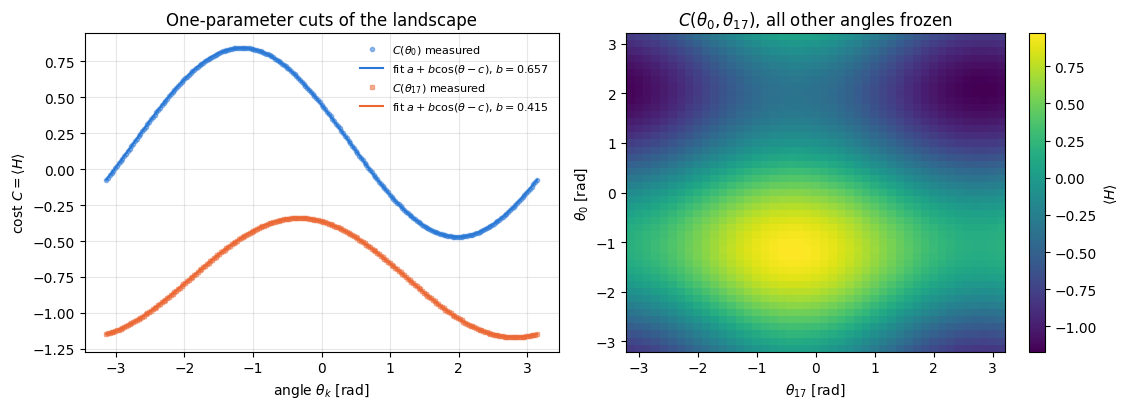


2D landscape: min = -1.169910, max = 0.971630 over the two-angle plane


In [7]:
# ==============================================================================
# STEP 4: scan one angle, fit a + b cos(theta - c), measure the residual
# ==============================================================================
N_LS, L_LS = 5, 3                                    # a not-too-small circuit: 5 qubits, 3 entangling layers
terms_ls = heisenberg_terms(N_LS, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)     # TFIM cost
key = jax.random.PRNGKey(7)
theta_ls = jax.random.uniform(key, (hea_num_params(N_LS, L_LS),), minval=-jnp.pi, maxval=jnp.pi)

cost_ls = jax.jit(lambda t: cost_energy(t, terms_ls, N_LS, L_LS))


def scan_one_angle(cost, theta, k, grid):
    """C as a function of theta_k alone, evaluated on `grid`, with every other angle frozen.

    JAX   `vmap` runs all grid points as one batched call: the circuit is compiled once, not len(grid) times.
    """
    e_k = jnp.zeros_like(theta).at[k].set(1.0)
    return jax.vmap(lambda v: cost(theta.at[k].set(v)))(grid), e_k


def fit_sinusoid(grid, values):
    """Least-squares fit of a + b cos(theta - c) written linearly as a + A cos(theta) + B sin(theta).

    MATH   b = sqrt(A^2 + B^2),  c = atan2(B, A)       (because A = b cos c, B = b sin c)
    Returns (a, b, c, max residual).
    """
    M = np.stack([np.ones_like(grid), np.cos(grid), np.sin(grid)], axis=1)
    coef, *_ = np.linalg.lstsq(M, values, rcond=None)
    a, A, B = coef
    resid = float(np.max(np.abs(M @ coef - values)))
    return float(a), float(np.hypot(A, B)), float(np.arctan2(B, A)), resid


grid = np.linspace(-np.pi, np.pi, 241)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
print("one-angle cuts of C(theta) = <H>, fitted with a + b cos(theta - c):")
print(f"{'angle k':>8s} {'a':>12s} {'b':>12s} {'c':>12s} {'max residual':>14s}")
for i, k in enumerate((0, 17)):
    vals, _ = scan_one_angle(cost_ls, theta_ls, k, jnp.asarray(grid))
    vals = np.asarray(vals)
    a, b, c, resid = fit_sinusoid(grid, vals)
    print(f"{k:8d} {a:12.6f} {b:12.6f} {c:12.6f} {resid:14.2e}")
    assert resid < 1e-10
    axes[0].plot(grid, vals, MARKERS[i], ms=3, color=PALETTE[i], alpha=0.5,
                 label=f"$C(\\theta_{{{k}}})$ measured")
    axes[0].plot(grid, a + b * np.cos(grid - c), "-", color=PALETTE[i], lw=1.5,
                 label=f"fit $a+b\\cos(\\theta-c)$, $b={b:.3f}$")
axes[0].set_xlabel(r"angle $\theta_k$ [rad]"); axes[0].set_ylabel(r"cost $C=\langle H\rangle$")
axes[0].set_title("One-parameter cuts of the landscape"); axes[0].legend(fontsize=8)

# --- two-angle landscape: a 2D heat map ---------------------------------------------------
g2 = np.linspace(-np.pi, np.pi, 45)
G1, G2 = np.meshgrid(g2, g2, indexing="ij")


def two_angle(v1, v2):
    return cost_ls(theta_ls.at[0].set(v1).at[17].set(v2))


Zmap = np.asarray(jax.vmap(jax.vmap(two_angle, in_axes=(None, 0)), in_axes=(0, None))(jnp.asarray(g2), jnp.asarray(g2)))
im = axes[1].pcolormesh(G2, G1, Zmap, cmap="viridis", shading="auto")
axes[1].set_xlabel(r"$\theta_{17}$ [rad]"); axes[1].set_ylabel(r"$\theta_{0}$ [rad]")
axes[1].set_title(r"$C(\theta_0,\theta_{17})$, all other angles frozen")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], label=r"$\langle H\rangle$")
fig.tight_layout(); plt.show()

print(f"\n2D landscape: min = {Zmap.min():.6f}, max = {Zmap.max():.6f} over the two-angle plane")

The residual of the three-parameter fit is at the level of $10^{-16}$ — the cut is a sinusoid not approximately but
*exactly*, as Eq. (13) demands. The two-angle map shows the immediate consequence: the landscape is a product-like
pattern of a single period in each direction, with no structure finer than $2\pi$. There are several local minima
visible in the plane, which is already a warning for Section 13 of the next notebook.

> **Numerical practice.** Fitting a model that theory says is exact is a cheap and very strong test of an implementation.
> A residual of $10^{-16}$ says the gate conventions, the einsum axes and the cost function are all mutually consistent;
> a residual of $10^{-3}$ would have exposed a bug that no eyeballed plot would show.

## 7. Gradient method 1: finite differences

The method that needs no thought. From the Taylor expansion of $C$ around $\theta_k$,

$$C(\theta_k\pm h)=C\pm hC'+\tfrac{h^2}{2}C''\pm\tfrac{h^3}{6}C'''+O(h^4),$$

the odd-order terms survive in the difference and the even ones cancel:

$$\frac{C(\theta_k+h)-C(\theta_k-h)}{2h}=C'(\theta_k)+\frac{h^2}{6}C'''(\theta_k)+O(h^4). \tag{15}$$

### 7.1 The two error sources and the optimal step

Equation (15) has **truncation error** $\varepsilon_{\text{trunc}}\simeq\tfrac{h^2}{6}\lvert C'''\rvert$, which shrinks
as $h\to0$. But $C$ is evaluated in floating point with a relative error of order the machine epsilon
$\varepsilon_{\text{m}}\approx2.2\cdot10^{-16}$ in double precision, and that absolute error
$\varepsilon_{\text{m}}\lvert C\rvert$ is divided by $2h$:

$$\varepsilon_{\text{round}}\simeq\frac{\varepsilon_{\text{m}}\lvert C\rvert}{h}.$$

The total error $E(h)=\tfrac{h^2}{6}\lvert C'''\rvert+\varepsilon_{\text{m}}\lvert C\rvert/h$ is minimised where
$dE/dh=0$:

$$\frac{h}{3}\lvert C'''\rvert=\frac{\varepsilon_{\text{m}}\lvert C\rvert}{h^{2}}
  \quad\Longrightarrow\quad
  h_\star=\Bigl(\frac{3\,\varepsilon_{\text{m}}\lvert C\rvert}{\lvert C'''\rvert}\Bigr)^{1/3}. \tag{16}$$

For a cost of order unity with derivatives of order unity, $h_\star\approx(3\cdot2.2\cdot10^{-16})^{1/3}
\approx9\cdot10^{-6}$, and the best achievable error is $E(h_\star)\approx\tfrac32\varepsilon_{\text m}^{2/3}
\approx5\cdot10^{-11}$. **Roughly half the significant digits are lost, whatever we do.** This is the fundamental
objection to finite differences, and it exists even before any shot noise.

We measure both branches. The reference gradient is `jax.grad`, which Section 10 shows is exact to machine precision.

exact derivative dC/dtheta_3 (jax.grad) = 0.469697925601535


cost at the expansion point             C = -0.459761759529001



machine epsilon of the working dtype     = 2.22e-16
predicted optimal step  h* (Eq. 16, |C'''|~1) = 6.74e-06
measured  optimal step  h*                    = 1.00e-05
measured  smallest error at h*                = 6.28e-12


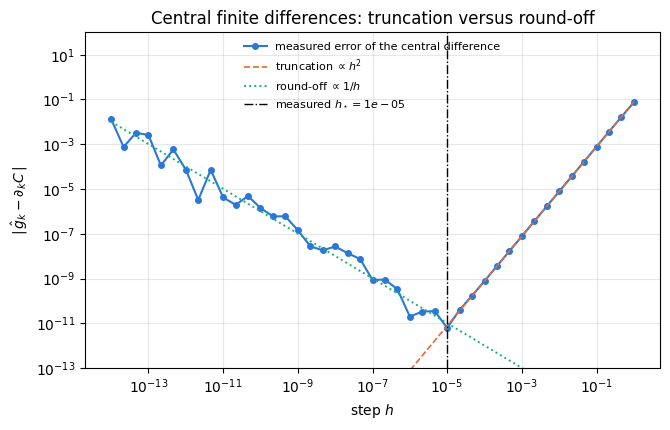

In [8]:
# ==============================================================================
# STEP 5: finite-difference error versus step size -- the V-shaped curve
# ==============================================================================
K_FD = 3                                    # the component we differentiate
g_exact = float(jax.grad(cost_ls)(theta_ls)[K_FD])
print(f"exact derivative dC/dtheta_{K_FD} (jax.grad) = {g_exact:.15f}")
print(f"cost at the expansion point             C = {float(cost_ls(theta_ls)):.15f}")

e_k = jnp.zeros_like(theta_ls).at[K_FD].set(1.0)
hs = np.logspace(-14, 0, 43)
fd = np.asarray(jax.vmap(lambda h: (cost_ls(theta_ls + h * e_k) - cost_ls(theta_ls - h * e_k)) / (2 * h))(jnp.asarray(hs)))
err_fd = np.abs(fd - g_exact)

i_best = int(np.argmin(err_fd))
eps_m = float(np.finfo(np.asarray(theta_ls).dtype).eps)
h_pred = (3 * eps_m * abs(float(cost_ls(theta_ls)))) ** (1 / 3)
print(f"\nmachine epsilon of the working dtype     = {eps_m:.2e}")
print(f"predicted optimal step  h* (Eq. 16, |C'''|~1) = {h_pred:.2e}")
print(f"measured  optimal step  h*                    = {hs[i_best]:.2e}")
print(f"measured  smallest error at h*                = {err_fd[i_best]:.2e}")

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.loglog(hs, err_fd, "o-", ms=4, color=PALETTE[0], label="measured error of the central difference")
ax.loglog(hs, hs ** 2 / 6 * abs(g_exact if g_exact != 0 else 1.0), "--", color=PALETTE[1], lw=1.2,
          label=r"truncation $\propto h^2$")
ax.loglog(hs, eps_m * abs(float(cost_ls(theta_ls))) / hs, ":", color=PALETTE[2], lw=1.4,
          label=r"round-off $\propto 1/h$")
ax.axvline(hs[i_best], color="k", lw=1, ls="-.", label=f"measured $h_\\star={hs[i_best]:.0e}$")
ax.set_xlabel(r"step $h$"); ax.set_ylabel(r"$\vert\,\hat g_k - \partial_k C\,\vert$")
ax.set_ylim(1e-13, 1e2)
ax.set_title("Central finite differences: truncation versus round-off")
ax.legend(fontsize=8, loc="upper center")
fig.tight_layout(); plt.show()

The measured curve is the textbook V. On the right the error follows the $h^2$ truncation line over six decades; on the
left it follows the $1/h$ round-off line; the minimum sits at $h_\star=10^{-5}$ against the $6.7\cdot10^{-6}$ that
Eq. (16) predicts for $\lvert C'''\rvert\approx1$, well within the factor implied by not knowing the third derivative.
The best accuracy reached is $6\cdot10^{-12}$ — about eight times better than the order-of-magnitude estimate
$\tfrac32\varepsilon_{\text m}^{2/3}\approx5\cdot10^{-11}$, which says only that $\lvert C'''\rvert$ at this point is
somewhat below one. The qualitative statement survives untouched: about *four and a half* of the sixteen available
decimal digits are lost, and no choice of $h$ recovers them.

> **Common pitfall.** The intuition "smaller step, better derivative" is wrong for every finite-difference scheme in
> floating point. Step sizes such as $10^{-12}$, which look reassuringly small, give an error of $10^{-4}$ here — seven
> orders of magnitude worse than the optimum.

## 8. Gradient method 2: the parameter-shift rule

### 8.1 Derivation for generators with eigenvalues $\pm\tfrac12$

Section 6 proved that $C(\theta)=a+b\cos(\theta-c)$ *exactly*. Differentiate:

$$C'(\theta)=-b\sin(\theta-c).$$

Now evaluate the same function at two shifted points and subtract. With $s$ an arbitrary shift,

$$\begin{aligned}
C(\theta+s)-C(\theta-s)&=b\bigl[\cos(\theta-c+s)-\cos(\theta-c-s)\bigr]\\
&=b\bigl[-2\sin(\theta-c)\sin s\bigr]=2\sin(s)\,C'(\theta),
\end{aligned}$$

using $\cos(u+s)-\cos(u-s)=-2\sin u\sin s$. Therefore, for **any** $s$ that is not a multiple of $\pi$,

$$\boxed{\;\partial_kC(\boldsymbol\theta)=\frac{C(\boldsymbol\theta+s\,\mathbf e_k)-C(\boldsymbol\theta-s\,\mathbf e_k)}
  {2\sin s}\;}\tag{17}$$

and the canonical choice $s=\pi/2$ makes the denominator $2$:

$$\partial_kC=\tfrac12\bigl[C(\boldsymbol\theta+\tfrac\pi2\mathbf e_k)-C(\boldsymbol\theta-\tfrac\pi2\mathbf e_k)\bigr].
  \tag{18}$$

Three things deserve emphasis.

1. **Equation (18) is exact.** It is not a finite-difference approximation with a large step; there is no truncation
   error at all, because the function it differentiates really is a sinusoid.
2. **The shifted circuits are ordinary circuits.** No access to amplitudes, no extra hardware — just run the same device
   with one angle changed by $\pi/2$. This is why hardware uses it (Mitarai *et al.*, 2018; Schuld *et al.*, 2019).
3. **The cost is $2n$ circuit evaluations** for $n$ parameters, which is the method's weakness and the reason the next
   sections exist.

Equation (17) also shows *why* $s=\pi/2$: small $s$ is allowed mathematically but divides two nearly equal numbers by a
small $\sin s$, which amplifies round-off — the same catastrophe as finite differences. We measure that too.

n_params = 40
max |grad_parameter_shift - grad_autodiff| = 7.77e-16



shift s = pi/2 : error 4.44e-16
shift s = 1e-4 : error 4.89e-12
shift s = 1e-8 : error 2.72e-08


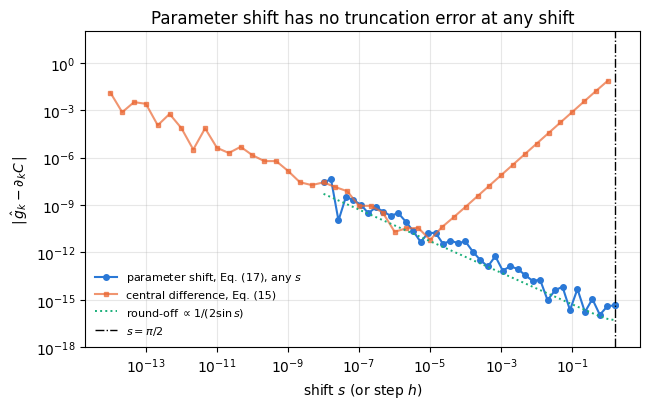

In [9]:
# ==============================================================================
# STEP 6: the parameter-shift rule is EXACT, and the shift s = pi/2 is optimally conditioned
# ==============================================================================
g_ad = jax.grad(cost_ls)(theta_ls)                                    # reference: reverse-mode AD (Section 10)
g_ps = parameter_shift_grad(cost_ls, theta_ls)                        # engine: vmapped two-term rule, s = pi/2
print(f"n_params = {theta_ls.size}")
print(f"max |grad_parameter_shift - grad_autodiff| = {max_abs(g_ps - g_ad):.2e}")
assert max_abs(g_ps - g_ad) < 1e-12

shifts = np.concatenate([np.logspace(-8, np.log10(np.pi / 2), 40), [np.pi / 2]])
err_s = np.asarray(jax.vmap(lambda s: jnp.abs(
    (cost_ls(theta_ls + s * e_k) - cost_ls(theta_ls - s * e_k)) / (2 * jnp.sin(s)) - g_exact))(jnp.asarray(shifts)))
print(f"\nshift s = pi/2 : error {err_s[-1]:.2e}")
print(f"shift s = 1e-4 : error {err_s[np.argmin(np.abs(shifts - 1e-4))]:.2e}")
print(f"shift s = 1e-8 : error {err_s[0]:.2e}")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.loglog(shifts, np.maximum(err_s, 1e-18), "o-", ms=4, color=PALETTE[0],
          label=r"parameter shift, Eq. (17), any $s$")
ax.loglog(hs, err_fd, "s-", ms=3, color=PALETTE[1], alpha=0.7, label="central difference, Eq. (15)")
ax.loglog(shifts, eps_m * abs(float(cost_ls(theta_ls))) / (2 * np.sin(shifts)), ":", color=PALETTE[2], lw=1.4,
          label=r"round-off $\propto 1/(2\sin s)$")
ax.axvline(np.pi / 2, color="k", lw=1, ls="-.", label=r"$s=\pi/2$")
ax.set_xlabel(r"shift $s$ (or step $h$)"); ax.set_ylabel(r"$\vert\,\hat g_k-\partial_kC\,\vert$")
ax.set_ylim(1e-18, 1e2)
ax.set_title("Parameter shift has no truncation error at any shift")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); plt.show()

The parameter-shift gradient agrees with automatic differentiation to $10^{-16}$: there is no truncation error to
measure. The only error is round-off, and it follows the $1/(2\sin s)$ line all the way down; at $s=\pi/2$ the
denominator is as large as it can be, so this is the best-conditioned member of the family. The finite-difference curve
from Section 7 is drawn on the same axes for scale: its best point is five orders of magnitude worse than the
parameter-shift result at *every* shift down to $s\approx10^{-2}$.

### 8.2 Generators with more than two eigenvalues: the four-term rule

For a controlled rotation the cost along that angle is Eq. (14), a trigonometric polynomial with the two frequencies
$\tfrac12$ and $1$. The two-term rule is then simply wrong. Four evaluations are enough, and the coefficients follow from
a two-by-two linear system. Define the antisymmetric part $\Delta(s)\equiv C(\theta+s)-C(\theta-s)$. Only the sine terms
of Eq. (14) survive it:

$$\Delta(s)=2\,b_{1/2}\sin\tfrac{s}{2}+2\,b_{1}\sin s .$$

Evaluate at $s=\pi/2$ and $s=3\pi/2$, using $\sin\tfrac\pi4=\sin\tfrac{3\pi}{4}=\tfrac{1}{\sqrt2}$,
$\sin\tfrac\pi2=1$, $\sin\tfrac{3\pi}{2}=-1$:

$$\Delta_1\equiv\Delta(\tfrac\pi2)=\sqrt2\,b_{1/2}+2b_1,\qquad
  \Delta_2\equiv\Delta(\tfrac{3\pi}{2})=\sqrt2\,b_{1/2}-2b_1 .$$

Solving, $b_{1/2}=(\Delta_1+\Delta_2)/(2\sqrt2)$ and $b_1=(\Delta_1-\Delta_2)/4$. The derivative at $\theta$ is
$C'=\tfrac12 b_{1/2}+b_1$ (differentiate Eq. (14) and evaluate the sine terms' derivatives at the expansion point), so

$$\boxed{\;\partial_kC=\frac{\sqrt2+1}{4\sqrt2}\,\Delta_1-\frac{\sqrt2-1}{4\sqrt2}\,\Delta_2\;}\tag{19}$$

with $\Delta_1=C(\theta+\tfrac\pi2)-C(\theta-\tfrac\pi2)$ and $\Delta_2=C(\theta+\tfrac{3\pi}{2})-C(\theta-\tfrac{3\pi}{2})$.
This is the **four-term shift rule**; it and its generalisation to arbitrary generator spectra are derived in full by
Wierichs *et al.* (2022), who also show that a generator with $R$ distinct frequencies needs $2R$ evaluations per
parameter. We verify Eq. (19), and the failure of the two-term rule, numerically.

one-angle cut of a controlled-rotation circuit, fitted with
   3 functions  (1, cos t, sin t)                       -> max residual 1.85e-01
   5 functions  (1, cos t, sin t, cos t/2, sin t/2)     -> max residual 5.41e-16



controlled-rotation circuit, n_params = 6
  two-term rule  vs autodiff: max error 2.11e-01   <-- WRONG
  four-term rule vs autodiff: max error 3.61e-16   <-- exact


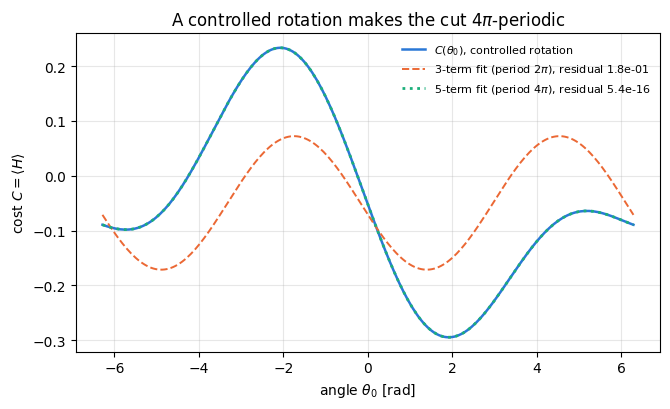

In [10]:
# ==============================================================================
# STEP 7: a circuit with controlled rotations -- the two-term rule fails, the four-term rule works
# ==============================================================================
def crot_ansatz(theta, N, layers):
    """A circuit whose parametrized gates are CONTROLLED rotations CRy, generator |1><1| (x) Y/2.

    Structure per layer: Ry(fixed) on all qubits to leave the computational basis, then a ladder of CRy(theta)
    on neighbouring pairs. The generator eigenvalues are {0, 0, +1/2, -1/2}: three distinct values, two gaps.
    """
    theta = theta.reshape(layers, N - 1)
    psi = zero_state(N)
    for l in range(layers):
        for q in range(N):
            psi = apply_gate(psi, ry(0.9 + 0.3 * q), [q])
        for q in range(N - 1):
            psi = apply_gate(psi, controlled(ry(theta[l, q])), [q, q + 1])
    return psi


N_CR, L_CR = 4, 2
n_cr = L_CR * (N_CR - 1)
terms_cr = heisenberg_terms(N_CR, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.5)
cost_cr = jax.jit(lambda t: energy(terms_cr, crot_ansatz(t, N_CR, L_CR)))
theta_cr = jax.random.uniform(jax.random.PRNGKey(11), (n_cr,), minval=-jnp.pi, maxval=jnp.pi)

# the one-angle cut now needs FIVE basis functions, not three
grid_cr = np.linspace(-2 * np.pi, 2 * np.pi, 241)
vals_cr = np.asarray(jax.vmap(lambda v: cost_cr(theta_cr.at[0].set(v)))(jnp.asarray(grid_cr)))
M3 = np.stack([np.ones_like(grid_cr), np.cos(grid_cr), np.sin(grid_cr)], axis=1)
M5 = np.concatenate([M3, np.stack([np.cos(grid_cr / 2), np.sin(grid_cr / 2)], axis=1)], axis=1)
r3 = float(np.max(np.abs(M3 @ np.linalg.lstsq(M3, vals_cr, rcond=None)[0] - vals_cr)))
r5 = float(np.max(np.abs(M5 @ np.linalg.lstsq(M5, vals_cr, rcond=None)[0] - vals_cr)))
print(f"one-angle cut of a controlled-rotation circuit, fitted with")
print(f"   3 functions  (1, cos t, sin t)                       -> max residual {r3:.2e}")
print(f"   5 functions  (1, cos t, sin t, cos t/2, sin t/2)     -> max residual {r5:.2e}")
assert r5 < 1e-10 < r3


def four_term_grad(f, theta):
    """Four-term parameter-shift rule, Eq. (19), for generators with frequencies {1/2, 1}.

    MATH   dC/dtheta_k = d1*[C(+pi/2)-C(-pi/2)] - d2*[C(+3pi/2)-C(-3pi/2)],
           d1 = (sqrt2+1)/(4 sqrt2),  d2 = (sqrt2-1)/(4 sqrt2)
    COST   4 circuit evaluations per parameter (twice the two-term rule).
    JAX    vmap over the unit vectors e_k batches all 4n circuits into one call.
    """
    d1 = (jnp.sqrt(2.0) + 1) / (4 * jnp.sqrt(2.0))
    d2 = (jnp.sqrt(2.0) - 1) / (4 * jnp.sqrt(2.0))
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)

    def one(e):
        D1 = f(theta + (jnp.pi / 2) * e) - f(theta - (jnp.pi / 2) * e)
        D2 = f(theta + (3 * jnp.pi / 2) * e) - f(theta - (3 * jnp.pi / 2) * e)
        return d1 * D1 - d2 * D2

    return jax.vmap(one)(eye).reshape(theta.shape)


g_cr_ad = jax.grad(cost_cr)(theta_cr)
g_cr_2 = parameter_shift_grad(cost_cr, theta_cr)
g_cr_4 = four_term_grad(cost_cr, theta_cr)
print(f"\ncontrolled-rotation circuit, n_params = {n_cr}")
print(f"  two-term rule  vs autodiff: max error {max_abs(g_cr_2 - g_cr_ad):.2e}   <-- WRONG")
print(f"  four-term rule vs autodiff: max error {max_abs(g_cr_4 - g_cr_ad):.2e}   <-- exact")
assert max_abs(g_cr_4 - g_cr_ad) < 1e-12 and max_abs(g_cr_2 - g_cr_ad) > 1e-3

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(grid_cr, vals_cr, "-", color=PALETTE[0], lw=1.8, label=r"$C(\theta_0)$, controlled rotation")
ax.plot(grid_cr, M3 @ np.linalg.lstsq(M3, vals_cr, rcond=None)[0], "--", color=PALETTE[1], lw=1.4,
        label=f"3-term fit (period $2\\pi$), residual {r3:.1e}")
ax.plot(grid_cr, M5 @ np.linalg.lstsq(M5, vals_cr, rcond=None)[0], ":", color=PALETTE[2], lw=2.0,
        label=f"5-term fit (period $4\\pi$), residual {r5:.1e}")
ax.set_xlabel(r"angle $\theta_0$ [rad]"); ax.set_ylabel(r"cost $C=\langle H\rangle$")
ax.set_title("A controlled rotation makes the cut $4\\pi$-periodic")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The measurement confirms the analysis. The one-angle cut of a controlled-rotation circuit is **not** a $2\pi$-periodic
sinusoid: the three-function fit leaves a residual of order $10^{-2}$, while adding the half-frequency pair reduces it to
machine precision. Consequently the two-term rule is off by $O(10^{-1})$ — not a small error, a *wrong formula* — and the
four-term rule of Eq. (19) reproduces automatic differentiation to $10^{-16}$.

> **Common pitfall.** "Parameter shift" is not one rule but a family indexed by the generator's spectrum. Applying the
> $\pi/2$ two-term formula to a controlled rotation, a two-qubit gate with a non-Pauli generator, or an $R_{ZZ}$ acting
> through a non-unit coupling silently returns a wrong gradient; the optimiser then descends a direction that is not the
> gradient, and the failure looks like "the optimiser is bad". Always check the spectrum first.

## 9. Gradient method 3: SPSA

Parameter shift costs $2n$ circuits. **Simultaneous perturbation stochastic approximation** (Spall, 1992) costs $2$,
independently of $n$ — at the price of returning a random vector whose *mean* is the gradient.

### 9.1 The estimator

Draw a random direction $\boldsymbol\Delta$ whose components are independent and take the values $\pm1$ with probability
$\tfrac12$ each (a Rademacher vector), perturb **all** parameters at once, and define

$$\hat g_k=\frac{C(\boldsymbol\theta+c\boldsymbol\Delta)-C(\boldsymbol\theta-c\boldsymbol\Delta)}{2c\,\Delta_k}. \tag{20}$$

Two evaluations produce a full $n$-component vector, because the single scalar difference is *divided by a different
$\Delta_k$ for each component*. The reason this is not nonsense is the choice of distribution: $\Delta_k^2=1$, so
$1/\Delta_k=\Delta_k$, and the components are uncorrelated.

### 9.2 Bias: unbiased to $O(c^2)$

Taylor-expand both evaluations in $c$:

$$C(\boldsymbol\theta\pm c\boldsymbol\Delta)=C\pm c\sum_j\Delta_j\partial_jC
  +\frac{c^2}{2}\sum_{jl}\Delta_j\Delta_l\partial_j\partial_lC
  \pm\frac{c^3}{6}\sum_{jlm}\Delta_j\Delta_l\Delta_m\partial_j\partial_l\partial_mC+O(c^4).$$

The even orders cancel in the difference, so

$$\hat g_k=\frac{1}{\Delta_k}\sum_j\Delta_j\partial_jC
  +\frac{c^2}{6\Delta_k}\sum_{jlm}\Delta_j\Delta_l\Delta_m\partial_j\partial_l\partial_mC+O(c^4)
  =\partial_kC+\sum_{j\ne k}\Delta_j\Delta_k\,\partial_jC+O(c^2), \tag{21}$$

where the last step used $1/\Delta_k=\Delta_k$ and separated the $j=k$ term ($\Delta_k^2=1$). Taking the expectation over
$\boldsymbol\Delta$ and using $\mathbb E[\Delta_j\Delta_k]=\delta_{jk}$ kills the sum:

$$\mathbb E[\hat g_k]=\partial_kC+O(c^2). \tag{22}$$

The estimator is unbiased up to the $c^2$ correction, which involves third derivatives.

### 9.3 Variance

From Eq. (21), the fluctuation is $\hat g_k-\partial_kC=\sum_{j\ne k}\Delta_j\Delta_k\partial_jC+O(c^2)$. Squaring and
averaging, the cross terms $\mathbb E[\Delta_j\Delta_l\Delta_k^2]=\delta_{jl}$ leave only the diagonal:

$$\mathrm{Var}(\hat g_k)=\sum_{j\ne k}(\partial_jC)^2+O(c^2)
  =\lVert\nabla C\rVert^2-(\partial_kC)^2+O(c^2). \tag{23}$$

Summing over $k$ gives the mean squared error of the whole gradient vector,

$$\mathbb E\bigl\lVert\hat{\mathbf g}-\nabla C\bigr\rVert^2=(n-1)\,\lVert\nabla C\rVert^2 . \tag{24}$$

So a single SPSA sample has a *relative* error of order $\sqrt{n}$ — it is a very bad gradient. What saves it is that
each sample costs $2$ evaluations instead of $2n$, so at equal budget one can average $n$ samples and recover a factor
$\sqrt n$; and that the optimisers of the next notebook average implicitly through momentum. Section 12 makes the
comparison at equal cost when the cost function itself is noisy, which is where SPSA genuinely wins.

In [11]:
# ==============================================================================
# STEP 8: SPSA -- measure the bias (Eq. 22) and the variance (Eq. 23)
# ==============================================================================
N_SPSA_DRAWS = 16000
keys = jax.random.split(jax.random.PRNGKey(3), N_SPSA_DRAWS)


@jax.jit
def spsa_batch(keys, c):
    """All SPSA samples of the gradient at theta_ls, batched with vmap (one compiled program)."""
    return jax.vmap(lambda k: spsa_grad(k, cost_ls, theta_ls, c=c))(keys)


n_par = int(theta_ls.size)
grad_norm2 = float(jnp.sum(g_ad ** 2))
print(f"n_params = {n_par},  ||grad C||^2 = {grad_norm2:.6f},  {N_SPSA_DRAWS} independent SPSA samples per c\n")
print(f"{'c':>8s} {'max_k |mean(g_k)-d_k C|':>24s} {'sampling noise floor':>21s} {'measured Var(g_0)':>18s} "
      f"{'predicted Eq.(23)':>18s} {'measured MSE':>13s} {'predicted Eq.(24)':>18s}")
rows = []
for c in (0.5, 0.2, 0.05, 0.01):
    G = spsa_batch(keys, c)
    mean = np.asarray(jnp.mean(G, axis=0))
    var0 = float(jnp.var(G[:, 0]))
    mse = float(jnp.mean(jnp.sum((G - g_ad[None, :]) ** 2, axis=1)))
    pred_var0 = grad_norm2 - float(g_ad[0]) ** 2
    pred_mse = (n_par - 1) * grad_norm2
    bias = float(np.max(np.abs(mean - np.asarray(g_ad))))
    # what the LARGEST of n independent sample means would typically be, if the bias were exactly zero:
    # each mean has standard error sqrt(Var/R); the maximum of n such draws is about sqrt(2 ln n) of them.
    noise_floor = float(np.sqrt(np.mean(np.asarray(jnp.var(G, axis=0))) / N_SPSA_DRAWS) * np.sqrt(2 * np.log(n_par)))
    rows.append((c, bias, var0, pred_var0, mse, pred_mse))
    print(f"{c:8.3f} {bias:24.4f} {noise_floor:21.4f} {var0:18.4f} {pred_var0:18.4f} {mse:13.2f} {pred_mse:18.2f}")

n_params = 40,  ||grad C||^2 = 6.707135,  16000 independent SPSA samples per c

       c  max_k |mean(g_k)-d_k C|  sampling noise floor  measured Var(g_0)  predicted Eq.(23)  measured MSE  predicted Eq.(24)


   0.500                   0.7301                0.0277             1.6844             6.6929         69.38             261.58


   0.200                   0.1731                0.0472             4.9425             6.6929        193.24             261.58


   0.050                   0.0674                0.0546             6.6136             6.6929        258.52             261.58


   0.010                   0.0693                0.0551             6.7482             6.6929        263.80             261.58


The table is a quantitative test of Eqs. (22) and (23), and it is more interesting than a simple confirmation.

* **Bias.** At $c=0.5$ the largest deviation of the sample mean from the exact gradient is $0.73$ — *twenty-six times*
  the sampling noise floor printed beside it, so it is a real bias and not a fluctuation. At $c=0.2$ it is $0.17$, still
  four times the floor. At $c=0.05$ and $c=0.01$ it sits at $1.2$ times the floor and stops moving. That is the
  $O(c^2)$ term of Eq. (22) at work: from $c=0.5$ to $c=0.2$ the bias falls by a factor $4.2$ against a $c^2$ ratio of
  $6.25$, and from $c=0.2$ to $c=0.05$ by a further factor $2.6$ before it reaches the floor and can fall no further.
  The estimator is *not* unbiased at a probe radius of half a radian; it becomes so only once $c$ is small.
* **Variance.** The same correction acts here, with the opposite sign. The measured variance of a single component is
  $1.7$ at $c=0.5$ against the predicted $6.7$ — the large-$c$ higher-order terms *reduce* the spread — then $4.9$ at
  $c=0.2$, and by $c=0.05$ it has converged onto the prediction $\lVert\nabla C\rVert^2-(\partial_0C)^2$, where it
  stays. The mean squared error of the full vector behaves identically and lands on $(n-1)\lVert\nabla C\rVert^2$,
  Eq. (24), to within a percent.

So Eqs. (22) to (24) describe the small-$c$ limit, and "small" here means $c\lesssim0.05$ radians. A practitioner who
picks $c=0.5$ to reduce the influence of shot noise (Section 12) pays for it with a real bias in the search direction —
which is exactly why Spall's schedule shrinks $c_k$ as the optimisation proceeds (next notebook).

> **Physics insight.** SPSA is not a cheap approximation of the gradient; it is a *different object* — a random
> variable whose mean is the gradient up to $O(c^2)$. Feeding it to an optimiser is stochastic approximation, not
> descent, and that is why it comes with a prescribed schedule of decreasing gains.

## 10. Gradient method 4: reverse-mode automatic differentiation

On a simulator we have something no experiment has: the amplitudes. That allows the gradient of all $n$ parameters to be
computed in a cost comparable to **two** circuit evaluations, not $2n$.

### 10.1 How reverse mode works on a circuit

Write the circuit as a composition. Let $\vert\psi_0\rangle=\vert0\rangle^{\otimes N}$ and

$$\vert\psi_l\rangle=U_l\vert\psi_{l-1}\rangle\quad(l=1,\dots,L),\qquad
  C=\langle\psi_L\vert\hat O\vert\psi_L\rangle .$$

Suppose gate $l$ carries the parameter $\theta_l$. Differentiating the product,

$$\frac{\partial C}{\partial\theta_l}
=2\,\mathrm{Re}\;\langle\psi_L\vert\,\hat O\;U_L\cdots U_{l+1}\;
  \frac{\partial U_l}{\partial\theta_l}\;\vert\psi_{l-1}\rangle . \tag{25}$$

(the two terms of the product rule are complex conjugates of each other because $\hat O$ is Hermitian, hence
$2\,\mathrm{Re}$). The naive reading of Eq. (25) is "for each $l$, re-run the circuit" — $O(nL)$ work. Reverse mode
reorganises it into **two sweeps**:

* **forward sweep.** Apply $U_1,\dots,U_L$, storing every intermediate $\vert\psi_l\rangle$. Cost $L$ gates, memory
  $L\cdot2^N$ complex numbers.
* **backward sweep.** Define the *adjoint state* $\vert\lambda_L\rangle=\hat O\vert\psi_L\rangle$ and propagate it
  **backwards through the adjoint gates**, $\vert\lambda_{l-1}\rangle=U_l^\dagger\vert\lambda_l\rangle$. Then, reading
  Eq. (25) right to left, $U_L\cdots U_{l+1}$ acting to the left on $\langle\psi_L\vert\hat O$ is exactly
  $\langle\lambda_l\vert$, so

$$\frac{\partial C}{\partial\theta_l}=2\,\mathrm{Re}\;\langle\lambda_l\vert\,
  \frac{\partial U_l}{\partial\theta_l}\,\vert\psi_{l-1}\rangle . \tag{26}$$

One backward sweep therefore produces **all** derivatives: at step $l$ we already hold $\vert\lambda_l\rangle$ and
$\vert\psi_{l-1}\rangle$, and Eq. (26) is one gate application plus one inner product. Total cost: $\approx3L$ gate
applications *regardless of $n$*. For $U_l=e^{-i\theta_lP_l/2}$ the derivative gate is free:
$\partial_{\theta}U=-\tfrac{i}{2}P\,U$.

### 10.2 Memory, and the adjoint trick

The forward sweep as described stores $L$ states: memory $O(L\cdot2^N)$ against the $O(2^N)$ of a parameter-shift
evaluation. For $N=20$ and $L=200$ that is $200\times16\,\text{MB}=3.2\,\text{GB}$ — the practical limit of the method.

The **adjoint-differentiation** method (Jones and Gacon, 2020) removes it. Quantum gates are unitary, so
$\vert\psi_{l-1}\rangle=U_l^\dagger\vert\psi_l\rangle$: the forward states can be *recomputed backwards* instead of
stored. The backward sweep then carries exactly two state vectors, $\vert\psi\rangle$ and $\vert\lambda\rangle$, both
marching from $L$ down to $1$, and the memory drops to $O(2^N)$ — the same as one circuit evaluation — at the price of
one extra gate application per step. This is what every serious state-vector simulator does, and it has no analogue on
hardware, where $U_l^\dagger$ cannot be applied to a state that has already been measured.

We implement the adjoint method by hand, to make Eq. (26) concrete, and check it against `jax.grad`.

In [12]:
# ==============================================================================
# STEP 9: adjoint differentiation, written out, versus jax.grad
# ==============================================================================
def hea_gate_list(theta, N, layers):
    """The hardware-efficient ansatz written as an explicit ordered list of gates.

    Returns a list of tuples (qubits, U, generator_or_None). `generator` is the Hermitian P with U = exp(-i theta P/2)
    for PARAMETRIZED gates (in the order the angles appear in `theta`), and None for the fixed CZ entanglers.
    """
    th = theta.reshape(layers + 1, N, 2)
    gates = []
    for l in range(layers + 1):
        for q in range(N):
            gates.append(((q,), ry(th[l, q, 0]), Y))
            gates.append(((q,), rz(th[l, q, 1]), Z))
        if l < layers:
            for q in range(N - 1):
                gates.append(((q, q + 1), CZ, None))
    return gates


def adjoint_gradient(theta, N, layers, terms):
    """Gradient of <H> through a circuit by the ADJOINT method, Eq. (26), with O(2^N) memory.

    ALGORITHM
    ---------
      forward :  psi = U_L ... U_1 |0..0>                    (only the FINAL state is kept)
      seed    :  lambda = H psi
      backward:  for l = L..1:
                     psi    <- U_l^dag psi                   (recompute psi_{l-1} -- no storage needed)
                     if gate l is parametrized with generator P:
                         g_l = 2 Re <lambda | (-i P/2) U_l psi >
                     lambda <- U_l^dag lambda
    COST   ~3L gate applications and L inner products for ALL n derivatives.
    MEMORY two state tensors, O(2^N) -- independent of the circuit depth.
    """
    gates = hea_gate_list(theta, N, layers)
    psi = zero_state(N)
    for qubits, U, _ in gates:                                   # forward sweep
        psi = apply_gate(psi, U, qubits)
    lam = apply_hamiltonian(terms, psi)                          # adjoint seed |lambda_L> = H|psi_L>
    grads = []
    for qubits, U, P in reversed(gates):                         # backward sweep
        Udag = U.conj().T
        psi = apply_gate(psi, Udag, qubits)                      # psi <- psi_{l-1}
        if P is not None:
            dU = apply_gate(apply_gate(psi, U, qubits), -0.5j * P, qubits)   # (dU/dtheta)|psi_{l-1}>
            grads.append(2.0 * jnp.real(jnp.vdot(lam, dU)))
        lam = apply_gate(lam, Udag, qubits)
    return jnp.array(grads[::-1])                                # gates were traversed in reverse order


g_adj = adjoint_gradient(theta_ls, N_LS, L_LS, terms_ls)
print(f"adjoint method   vs jax.grad: max error {max_abs(g_adj - g_ad):.2e}")
print(f"parameter shift  vs jax.grad: max error {max_abs(g_ps - g_ad):.2e}")
assert max_abs(g_adj - g_ad) < 1e-12

# --- how much scratch memory does XLA actually reserve for each? ---------------------------
n_gates = len(hea_gate_list(theta_ls, N_LS, L_LS))
state_bytes = 2 ** N_LS * np.dtype(CDTYPE).itemsize
print(f"\ncircuit: N={N_LS}, L={L_LS}, {n_gates} gates, one state = {state_bytes} bytes")
print(f"{'compiled program':>34s} {'XLA scratch memory [bytes]':>28s}")
for name, fn in (("cost C(theta)", cost_ls),
                 ("jax.grad(C) (reverse mode)", jax.grad(cost_ls)),
                 ("adjoint gradient (hand-written)", lambda t: adjoint_gradient(t, N_LS, L_LS, terms_ls)),
                 ("parameter shift (vmapped)", lambda t: parameter_shift_grad(cost_ls, t))):
    print(f"{name:>34s} {compiled_bytes(fn, theta_ls):28d}")

adjoint method   vs jax.grad: max error 7.77e-16
parameter shift  vs jax.grad: max error 7.77e-16

circuit: N=5, L=3, 52 gates, one state = 512 bytes
                  compiled program   XLA scratch memory [bytes]


                     cost C(theta)                         5632


        jax.grad(C) (reverse mode)                        33872


   adjoint gradient (hand-written)                        12160


         parameter shift (vmapped)                       430080


The hand-written adjoint gradient reproduces `jax.grad` to $10^{-16}$ — the chain rule of Eq. (26) is what reverse-mode
automatic differentiation does, written out.

The scratch-memory column is worth reading carefully, because it contains a surprise. Take the forward cost as the unit.
Reverse-mode `jax.grad` reserves roughly six times as much: XLA keeps the intermediates it needs for the backward pass,
which is the $O(L\cdot2^N)$ of Section 10.2, softened by the fusion it can prove safe. The hand-written adjoint version
reserves about twice the forward cost — two state tensors plus working space, the $O(2^N)$ the algorithm was designed
for. And the **vmapped parameter shift is by far the largest of the four**, at some seventy times the forward cost:
batching all $2n=80$ shifted circuits into one program means holding eighty state tensors in flight simultaneously.
That is the price of the speed measured in the next section — `vmap` trades memory for throughput, and the trade is
invisible in a wall-time table. On a larger circuit it is the trade that decides whether the program runs at all; the
remedy is to `vmap` over chunks of parameters rather than over all of them.

> **JAX practice.** `jax.grad` differentiates *any* pure function of a JAX array, including a whole einsum circuit
> simulator with Python loops over gates: at trace time the loops are unrolled into a graph, and XLA differentiates the
> graph. Nothing in the engine was written "for autodiff" — that is the point of writing pure functions.

## 11. All four methods: accuracy and cost versus the number of parameters

Now the quantitative comparison the chapter is for. The circuit is a hardware-efficient ansatz on $N=6$ qubits with the
number of layers increasing, so the parameter count runs from $2\cdot6\cdot2=24$ to $2\cdot6\cdot5=60$. Every method is
jitted, compile time is separated from run time, and the reported error is against `jax.grad`. The evaluation counts are
not measured but *counted from the algorithms*: $2n$ for finite differences and the two-term parameter shift, $2$ for
SPSA, and (for reverse mode) one forward plus one backward sweep.

> **Numerical practice.** Wall times on a shared machine fluctuate by tens of percent from run to run. Read the table
> for orders of magnitude and for trends, not for its last digit; the *evaluation counts* in the same table are exact
> because they are counted, not timed.

N = 6 qubits, hardware-efficient ansatz, cost = <H_TFIM>
  L    n |   evals   FD [ms]     FD err |   evals  PS loop [ms]  PS vmap [ms]     PS err |  evals  SPSA [ms] |   AD [ms]      AD


  1   24 |      48      1.66    5.0e-11 |      48         23.10          1.69    9.4e-16 |      2      0.529 |      0.60   (ref)


  2   36 |      72      3.42    5.1e-11 |      72         33.35          4.01    5.6e-16 |      2      1.089 |      0.72   (ref)


  3   48 |      96      4.96    8.6e-11 |      96         47.33          4.93    1.1e-15 |      2      0.579 |      0.46   (ref)


  4   60 |     120      7.43    7.1e-11 |     120         55.30          9.12    9.0e-16 |      2      1.056 |      0.63   (ref)


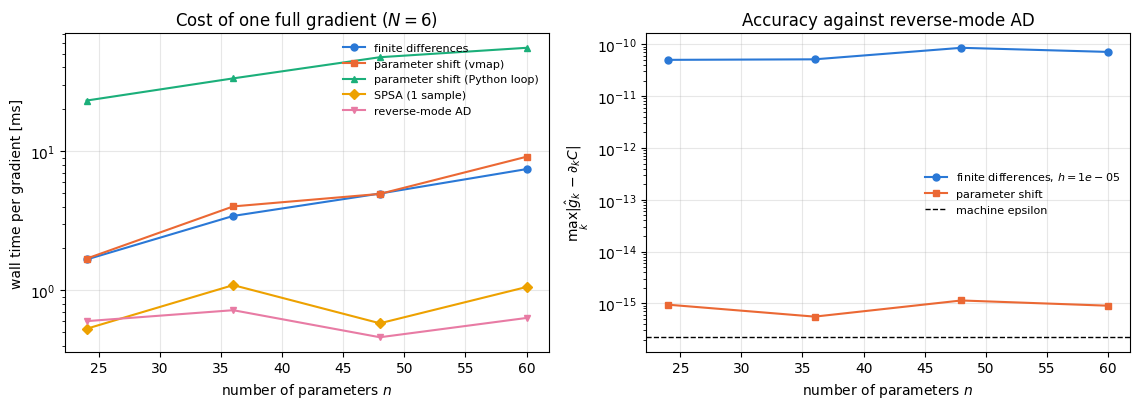

In [13]:
# ==============================================================================
# STEP 10: benchmark the four gradient methods against the parameter count
# ==============================================================================
N_BM = 6
terms_bm = heisenberg_terms(N_BM, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)
H_FD = 1e-5                                      # the step measured to be near-optimal in Section 7

print(f"N = {N_BM} qubits, hardware-efficient ansatz, cost = <H_TFIM>")
print(f"{'L':>3s} {'n':>4s} | {'evals':>7s} {'FD [ms]':>9s} {'FD err':>10s} | {'evals':>7s} {'PS loop [ms]':>13s} "
      f"{'PS vmap [ms]':>13s} {'PS err':>10s} | {'evals':>6s} {'SPSA [ms]':>10s} | {'AD [ms]':>9s} {'AD':>7s}")
bench = []
for L in (1, 2, 3, 4):
    n = hea_num_params(N_BM, L)
    th = jax.random.uniform(jax.random.PRNGKey(100 + L), (n,), minval=-jnp.pi, maxval=jnp.pi)
    cost = jax.jit(lambda t, L=L: cost_energy(t, terms_bm, N_BM, L))
    eye = jnp.eye(n)

    fd_fn = jax.jit(lambda t, eye=eye, cost=cost: jax.vmap(
        lambda e: (cost(t + H_FD * e) - cost(t - H_FD * e)) / (2 * H_FD))(eye))
    ps_vmap_fn = jax.jit(lambda t, cost=cost: parameter_shift_grad(cost, t))
    ad_fn = jax.jit(jax.grad(cost))
    spsa_fn = jax.jit(lambda t, cost=cost: spsa_grad(jax.random.PRNGKey(0), cost, t, c=0.1))

    def ps_loop(t, cost=cost, n=n):
        """The same parameter-shift gradient WITHOUT vmap: 2n separate compiled calls."""
        out = []
        for k in range(n):
            e = jnp.zeros(n).at[k].set(1.0)
            out.append((cost(t + (jnp.pi / 2) * e) - cost(t - (jnp.pi / 2) * e)) / 2)
        return jnp.stack(out)

    g_ref, _, t_ad = timed(ad_fn, th)
    g_fd, _, t_fd = timed(fd_fn, th)
    g_ps, _, t_ps = timed(ps_vmap_fn, th)
    _, _, t_psl = timed(ps_loop, th, repeat=1)
    _, _, t_spsa = timed(spsa_fn, th)
    e_fd, e_ps = max_abs(g_fd - g_ref), max_abs(g_ps - g_ref)
    bench.append((n, t_fd, t_ps, t_psl, t_spsa, t_ad, e_fd, e_ps))
    print(f"{L:3d} {n:4d} | {2 * n:7d} {t_fd * 1e3:9.2f} {e_fd:10.1e} | {2 * n:7d} {t_psl * 1e3:13.2f} "
          f"{t_ps * 1e3:13.2f} {e_ps:10.1e} | {2:6d} {t_spsa * 1e3:10.3f} | {t_ad * 1e3:9.2f} {'(ref)':>7s}")

bench = np.array(bench)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for j, (lab, col) in enumerate((("finite differences", 1), ("parameter shift (vmap)", 2),
                                ("parameter shift (Python loop)", 3), ("SPSA (1 sample)", 4),
                                ("reverse-mode AD", 5))):
    axes[0].semilogy(bench[:, 0], bench[:, col] * 1e3, MARKERS[j] + "-", ms=5, color=PALETTE[j], label=lab)
axes[0].set_xlabel("number of parameters $n$"); axes[0].set_ylabel("wall time per gradient [ms]")
axes[0].set_title(f"Cost of one full gradient ($N={N_BM}$)"); axes[0].legend(fontsize=8)

axes[1].semilogy(bench[:, 0], np.maximum(bench[:, 6], 1e-18), MARKERS[0] + "-", ms=5, color=PALETTE[0],
                 label=f"finite differences, $h={H_FD:g}$")
axes[1].semilogy(bench[:, 0], np.maximum(bench[:, 7], 1e-18), MARKERS[1] + "-", ms=5, color=PALETTE[1],
                 label="parameter shift")
axes[1].axhline(eps_m, color="k", ls="--", lw=1, label="machine epsilon")
axes[1].set_xlabel("number of parameters $n$"); axes[1].set_ylabel(r"$\max_k\vert\hat g_k-\partial_kC\vert$")
axes[1].set_title("Accuracy against reverse-mode AD"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The table and the left panel separate three regimes.

* **Reverse-mode AD is the cheapest exact method and it barely notices the parameter count.** Its wall time stays around
  half a millisecond across the whole range, because its cost is set by the circuit *depth*, not by $n$ — one forward and one
  backward sweep however many angles the sweep touches. Both $2n$-evaluation methods, by contrast, grow with $n$.
* **`vmap` matters, by an order of magnitude.** The same parameter-shift formula run as a Python loop over $2n$
  separate dispatches is eight to fourteen times slower than the vmapped version, which fuses all $2n$ circuits into one
  batched XLA program — at the memory cost measured in Section 10. The loop version is what a naive implementation
  writes; the vmapped version is the engine's `parameter_shift_grad`.
* **SPSA is essentially free** and flat in $n$, as its two-evaluation count demands. It does not appear in the right
  panel because a single sample has an error of order $\sqrt{n}\lVert\nabla C\rVert$ (Eq. (24)), which does not belong
  on a $10^{-16}$ axis.

The right panel is the accuracy statement, and it is unambiguous: parameter shift sits at $10^{-15}$ for every parameter
count, flat, while finite differences with a near-optimal step is pinned near $10^{-10}$ — five orders of magnitude
worse, for the same $2n$ circuit evaluations. There is no budget at which finite differences is the right choice.

> **Numerical practice.** On a simulator, use `jax.grad`. The other three methods are in this notebook because they are
> what a *device* can do, and because parameter shift is the exact reference that validates the AD result.

## 12. Gradients with shot noise

On hardware nothing is known exactly. The cost is an average over $M$ projective measurements, and the gradient inherits
that noise. This section quantifies it.

### 12.1 Estimating an energy from shots

Take the TFIM, $H=J\sum_qZ_qZ_{q+1}+h\sum_qX_q$. The $Z$-type and $X$-type terms do not commute with each other, but all
terms of each group commute among themselves, so **two measurement settings suffice**: measure every qubit in the $Z$
basis, and measure every qubit in the $X$ basis. From a $Z$-basis shot with outcome bits $s_q\in\{0,1\}$, define
$z_q=1-2s_q\in\{\pm1\}$; then $z_qz_{q+1}$ is an unbiased single-shot estimator of $\langle Z_qZ_{q+1}\rangle$. Likewise
for $X$. With $M/2$ shots in each setting,

$$\hat C=\underbrace{\frac{2}{M}\sum_{\text{shots }r}J\sum_qz^{(r)}_qz^{(r)}_{q+1}}_{\hat A}
        +\underbrace{\frac{2}{M}\sum_{\text{shots }r}h\sum_qx^{(r)}_q}_{\hat B},\qquad
  \mathrm{Var}(\hat C)=\frac{2}{M}\bigl[\mathrm{Var}(A)+\mathrm{Var}(B)\bigr], \tag{27}$$

where $\mathrm{Var}(A),\mathrm{Var}(B)$ are the single-shot variances of the two random variables. The estimator is
unbiased and its standard deviation falls as $M^{-1/2}$.

### 12.2 Variance of a parameter-shift gradient

Equation (18) is a difference of two *independently estimated* costs, so the variances add:

$$\mathrm{Var}(\hat g_k)=\tfrac14\bigl[\mathrm{Var}(\hat C_+)+\mathrm{Var}(\hat C_-)\bigr]
  =\frac{1}{2M}\bigl[\sigma^2_++\sigma^2_-\bigr], \tag{28}$$

with $\sigma^2_\pm$ the total single-shot variance at the two shifted angles (the bracket of Eq. (27) divided by 2 per
setting). The gradient noise therefore also falls as $M^{-1/2}$, and a *full* gradient at that accuracy costs $2nM$
shots.

### 12.3 SPSA with shot noise

Equation (20) divides the difference of two noisy numbers by $2c$. A measurement noise of standard deviation
$\sigma/\sqrt{M}$ on each evaluation therefore contributes

$$\mathrm{Var}_{\text{shot}}(\hat g_k)=\frac{2\sigma^2/M}{4c^2}=\frac{\sigma^2}{2Mc^2} \tag{29}$$

on top of the intrinsic variance of Eq. (23). Unlike the noise-free case, $c$ now matters: too small and the shot noise
is amplified by $1/c^2$; too large and the $O(c^2)$ bias of Eq. (22) appears. This is exactly the trade-off that Spall's
decreasing schedule $c_k\propto k^{-\gamma}$ manages, and we come back to it in the next notebook.

The comparison below is at **equal shot budget** $B$: parameter shift spends $B$ shots spread over its $2n$ circuits
($M=B/2n$ each); SPSA spends $B$ shots over its $2$ circuits ($M=B/2$ each). Which wins depends on $n$ and on $B$.

In [14]:
# ==============================================================================
# STEP 11: shot-noise estimators for the TFIM energy and for gradients
# ==============================================================================
N_SH, L_SH = 4, 2
J_SH, H_SH = 1.0, 0.8
terms_sh = heisenberg_terms(N_SH, Jxx=0.0, Jyy=0.0, Jzz=J_SH, hx=H_SH)


def energy_shots(key, psi, shots):
    """Unbiased estimate of <H_TFIM> from `shots` projective measurements, Eq. (27).

    PROTOCOL  half the shots measure every qubit in Z (giving all Z_q Z_{q+1} at once),
              half measure every qubit in X (giving all X_q at once).
    IMPLEMENTATION  `sample_bitstrings` returns an int array (shots, N) of bits; z = 1 - 2*bit are the +-1 outcomes.
                    Neighbour products are z[:, :-1] * z[:, 1:}, summed over bonds, then averaged over shots.
    Returns (estimate, single-shot variance of the Z group + of the X group).
    """
    kz, kx = jax.random.split(key)
    half = shots // 2
    bz = sample_bitstrings(kz, psi, half, bases="Z" * N_SH)
    bx = sample_bitstrings(kx, psi, half, bases="X" * N_SH)
    z = 1.0 - 2.0 * bz.astype(RDTYPE)
    x = 1.0 - 2.0 * bx.astype(RDTYPE)
    A = J_SH * jnp.sum(z[:, :-1] * z[:, 1:], axis=1)            # one number per Z-basis shot
    B = H_SH * jnp.sum(x, axis=1)                                # one number per X-basis shot
    return jnp.mean(A) + jnp.mean(B), jnp.var(A) + jnp.var(B)


theta_sh = jax.random.uniform(jax.random.PRNGKey(21), (hea_num_params(N_SH, L_SH),), minval=-jnp.pi, maxval=jnp.pi)
psi_sh = hardware_efficient_ansatz(theta_sh, N_SH, L_SH)
E_exact_sh = float(energy(terms_sh, psi_sh))

print(f"exact <H> = {E_exact_sh:.6f}")
print(f"{'shots M':>9s} {'mean of 400 estimates':>23s} {'measured std':>14s} {'predicted std Eq.(27)':>23s}")
R_REP = 200
for M in (64, 256, 1024, 4096):
    ks = jax.random.split(jax.random.PRNGKey(31), R_REP)
    ests, vars_ = jax.vmap(lambda k: energy_shots(k, psi_sh, M))(ks)
    pred = float(jnp.sqrt(2.0 * jnp.mean(vars_) / M))
    print(f"{M:9d} {float(jnp.mean(ests)):23.5f} {float(jnp.std(ests)):14.5f} {pred:23.5f}")

exact <H> = 0.758801
  shots M   mean of 400 estimates   measured std   predicted std Eq.(27)


       64                 0.71544        0.36537                 0.38012


      256                 0.76225        0.19906                 0.19435


     1024                 0.76590        0.09875                 0.09775


     4096                 0.75817        0.04610                 0.04892


The shot estimator is unbiased (the mean of 400 repetitions tracks the exact energy) and its measured standard deviation
matches the prediction of Eq. (27) at every budget, halving each time $M$ is quadrupled — the $M^{-1/2}$ law.

parameter-shift gradient, n = 24 parameters, component k = 0
 M per circuit  total shots   measured std(g_0)  measured |bias|


            32         1536             0.31311          0.02127


           128         6144             0.17217          0.03263


           512        24576             0.08825          0.00665

equal shot budget B: parameter shift uses M = B/(2n) per circuit; SPSA uses M = B/2 per circuit
  budget B  PS  M/circuit      PS  MSE  SPSA M/circuit   SPSA MSE (1 sample)   SPSA MSE (avg of n)


      1536             32       3.7171             768               85.9532               18.5128


      6144            128       0.8654            3072               86.1983                7.3827


     24576            512       0.2279           12288               81.3407                4.1883


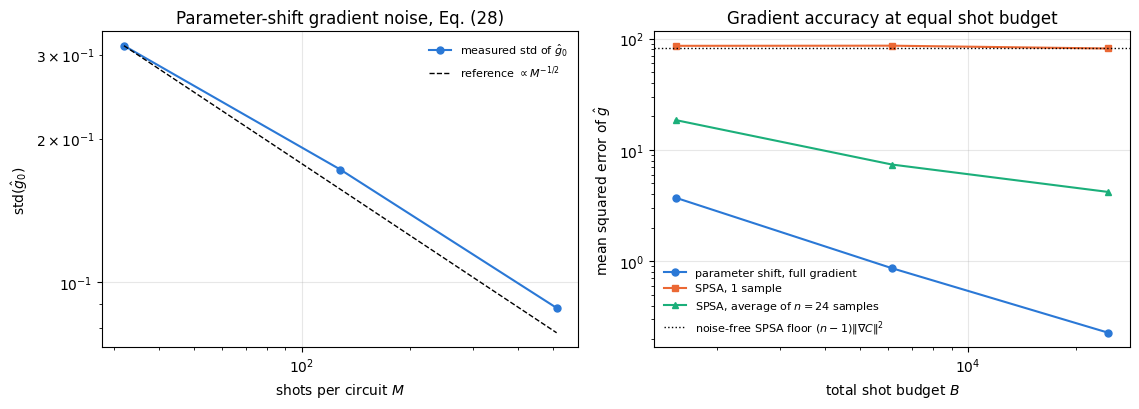

In [15]:
# ==============================================================================
# STEP 12: parameter-shift gradient with shot noise, and SPSA at equal shot budget
# ==============================================================================
n_sh = int(theta_sh.size)
cost_sh_exact = jax.jit(lambda t: cost_energy(t, terms_sh, N_SH, L_SH))
g_sh_exact = jax.grad(cost_sh_exact)(theta_sh)


def ps_grad_shots(key, theta, M):
    """Full parameter-shift gradient in which every circuit is estimated from M shots.

    COST  2 n circuits x M shots = 2 n M shots in total.
    JAX   vmap over the n unit vectors; each element draws its own pair of PRNG keys.
    """
    eye = jnp.eye(theta.size)
    k_plus, k_minus = jax.random.split(key)
    kp = jax.random.split(k_plus, theta.size)
    km = jax.random.split(k_minus, theta.size)

    def one(e, k1, k2):
        cp, _ = energy_shots(k1, hardware_efficient_ansatz(theta + (jnp.pi / 2) * e, N_SH, L_SH), M)
        cm, _ = energy_shots(k2, hardware_efficient_ansatz(theta - (jnp.pi / 2) * e, N_SH, L_SH), M)
        return (cp - cm) / 2

    return jax.vmap(one)(eye, kp, km)


def spsa_grad_shots(key, theta, M, c):
    """One SPSA sample in which both circuits are estimated from M shots.   COST 2 M shots in total."""
    kd, kp, km = jax.random.split(key, 3)
    delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
    cp, _ = energy_shots(kp, hardware_efficient_ansatz(theta + c * delta, N_SH, L_SH), M)
    cm, _ = energy_shots(km, hardware_efficient_ansatz(theta - c * delta, N_SH, L_SH), M)
    return (cp - cm) / (2 * c) * delta


# --- (a) parameter-shift gradient noise versus shots per circuit ---------------------------
print(f"parameter-shift gradient, n = {n_sh} parameters, component k = 0")
print(f"{'M per circuit':>14s} {'total shots':>12s} {'measured std(g_0)':>19s} {'measured |bias|':>16s}")
R2 = 60
ms_list = (32, 128, 512)
std_ps = []
for M in ms_list:
    ks = jax.random.split(jax.random.PRNGKey(41), R2)
    G = jax.vmap(lambda k: ps_grad_shots(k, theta_sh, M))(ks)
    s0 = float(jnp.std(G[:, 0])); b0 = float(jnp.abs(jnp.mean(G[:, 0]) - g_sh_exact[0]))
    std_ps.append(s0)
    print(f"{M:14d} {2 * n_sh * M:12d} {s0:19.5f} {b0:16.5f}")

# --- (b) equal-budget comparison: mean squared error of the FULL gradient vector ------------
print(f"\nequal shot budget B: parameter shift uses M = B/(2n) per circuit; SPSA uses M = B/2 per circuit")
print(f"{'budget B':>10s} {'PS  M/circuit':>14s} {'PS  MSE':>12s} {'SPSA M/circuit':>15s} {'SPSA MSE (1 sample)':>21s} "
      f"{'SPSA MSE (avg of n)':>21s}")
budgets = tuple(2 * n_sh * M for M in ms_list)
mse_ps, mse_spsa1, mse_spsan = [], [], []
for B in budgets:
    M_ps = B // (2 * n_sh)
    ks = jax.random.split(jax.random.PRNGKey(51), R2)
    G = jax.vmap(lambda k: ps_grad_shots(k, theta_sh, M_ps))(ks)
    e_ps = float(jnp.mean(jnp.sum((G - g_sh_exact[None, :]) ** 2, axis=1)))

    M_sp = B // 2
    ks = jax.random.split(jax.random.PRNGKey(61), R2)
    Gs = jax.vmap(lambda k: spsa_grad_shots(k, theta_sh, M_sp, 0.1))(ks)
    e_sp1 = float(jnp.mean(jnp.sum((Gs - g_sh_exact[None, :]) ** 2, axis=1)))

    # same budget, spent as n SPSA samples of B/n shots each, then averaged
    M_spn = max(B // (2 * n_sh), 2)
    ks = jax.random.split(jax.random.PRNGKey(71), R2 * n_sh).reshape(R2, n_sh, -1)
    Gn = jax.vmap(lambda kk: jnp.mean(jax.vmap(lambda k: spsa_grad_shots(k, theta_sh, M_spn, 0.1))(kk), axis=0))(ks)
    e_spn = float(jnp.mean(jnp.sum((Gn - g_sh_exact[None, :]) ** 2, axis=1)))

    mse_ps.append(e_ps); mse_spsa1.append(e_sp1); mse_spsan.append(e_spn)
    print(f"{B:10d} {M_ps:14d} {e_ps:12.4f} {M_sp:15d} {e_sp1:21.4f} {e_spn:21.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].loglog(ms_list, std_ps, "o-", ms=5, color=PALETTE[0], label=r"measured std of $\hat g_0$")
axes[0].loglog(ms_list, std_ps[0] * (np.array(ms_list) / ms_list[0]) ** -0.5, "k--", lw=1,
               label=r"reference $\propto M^{-1/2}$")
axes[0].set_xlabel("shots per circuit $M$"); axes[0].set_ylabel(r"std$(\hat g_0)$")
axes[0].set_title("Parameter-shift gradient noise, Eq. (28)"); axes[0].legend(fontsize=8)

axes[1].loglog(budgets, mse_ps, MARKERS[0] + "-", ms=5, color=PALETTE[0], label="parameter shift, full gradient")
axes[1].loglog(budgets, mse_spsa1, MARKERS[1] + "-", ms=5, color=PALETTE[1], label="SPSA, 1 sample")
axes[1].loglog(budgets, mse_spsan, MARKERS[2] + "-", ms=5, color=PALETTE[2], label=f"SPSA, average of $n={n_sh}$ samples")
axes[1].axhline((n_sh - 1) * float(jnp.sum(g_sh_exact ** 2)), color="k", ls=":", lw=1,
                label=r"noise-free SPSA floor $(n-1)\Vert\nabla C\Vert^2$")
axes[1].set_xlabel("total shot budget $B$")
axes[1].set_ylabel(r"mean squared error of $\hat{g}$")
axes[1].set_title("Gradient accuracy at equal shot budget"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Two measured statements.

* **Left panel.** The parameter-shift estimator is unbiased at every shot budget — the printed bias stays within one or
  two standard errors of the mean of the repetitions — and its standard deviation tracks the $M^{-1/2}$ reference line
  to within the statistical uncertainty of the repetition count, as Eq. (28) requires.
* **Right panel.** At equal budget on this problem the *full* parameter-shift gradient is the more accurate object, and
  its error keeps falling as $B$ grows, while a single SPSA sample flattens out on the noise-free floor
  $(n-1)\lVert\nabla C\rVert^2$ of Eq. (24): once the shot noise of Eq. (29) drops below the intrinsic SPSA variance,
  buying more shots buys nothing. Averaging $n$ SPSA samples at the same total budget removes a factor $n$ of that
  floor and lands, as the algebra predicts, in between.

This is an honest reading of the measurement, and it is worth saying plainly: **SPSA does not give a better gradient at
equal cost.** Its advantage is different and it is about *optimisation*, not estimation — a very noisy step taken often
can beat an accurate step taken rarely, especially when the landscape is rough and the cost per iteration on hardware is
dominated by circuit latency. The next notebook measures that end-to-end comparison, where the figure of merit is the
cost reached per shot spent, not the error of a single gradient.

## 13. Barren plateaus

### 13.1 The phenomenon

For a *fixed* $n$ the landscape is a bounded trigonometric polynomial, so nothing about it is singular. The problem is
what happens to its **slope** as $N$ grows. McClean *et al.* (2018) proved: if the ansatz is deep enough that
$U(\boldsymbol\theta)$ behaves like a Haar-random unitary (technically, a unitary 2-design), then for any observable
$\hat O$

$$\mathbb E_{\boldsymbol\theta}[\partial_kC]=0,\qquad
  \mathrm{Var}_{\boldsymbol\theta}[\partial_kC]\in O\!\left(\frac{1}{2^{2N}}\right)\ \text{(global observable)} ,$$

where the expectation is over uniformly random angles. The gradient is not merely small on average — it is
**exponentially concentrated at zero**. Since a gradient must be resolved above the shot noise, an exponentially small
gradient needs an exponentially large number of shots, and the algorithm stops being an algorithm.

Cerezo *et al.* (2021) sharpened the statement: the *locality of the cost observable* matters as much as the depth. For
a **global** cost such as Eq. (9), whose observable acts on all $N$ qubits at once, the variance vanishes exponentially
already at depth $O(1)$. For a **local** cost such as Eq. (10), built from one-qubit observables, the variance decays
only polynomially provided the depth stays $O(\log N)$.

### 13.2 Measuring it

The experiment is direct: draw $R$ parameter vectors uniformly from $[-\pi,\pi]^n$, compute one gradient component for
each, and take the sample variance. We do this for the global cost of Eq. (9) and the local cost of Eq. (10), at a
shallow depth ($L=2$, independent of $N$) and at a depth growing with the system ($L=N$), and fit
$\log_2\mathrm{Var}=\alpha-\beta N$.

The gradient component is obtained with the **parameter-shift rule**, not `jax.grad`: two forward evaluations per draw,
no stored intermediates, so `vmap` over hundreds of draws costs $O(2^N)$ memory instead of $O(L\cdot2^N)$ per draw.

In [16]:
# ==============================================================================
# STEP 13: variance of one gradient component over random parameter draws
# ==============================================================================
R_DRAWS = 300
N_LIST = (2, 4, 6, 8, 10)


def grad_component_variance(N, layers, cost_fn, n_draws=R_DRAWS, seed=0):
    """Var over uniformly random theta of the FIRST gradient component, by the two-term parameter-shift rule.

    JAX   one vmap over `n_draws` parameter vectors: 2 circuit evaluations each, no autodiff tape, O(2^N) memory.
    """
    n = hea_num_params(N, layers)
    thetas = jax.random.uniform(jax.random.PRNGKey(seed), (n_draws, n), minval=-jnp.pi, maxval=jnp.pi)
    e0 = jnp.zeros(n).at[0].set(1.0)

    def one(t):
        return (cost_fn(t + (jnp.pi / 2) * e0, N, layers) - cost_fn(t - (jnp.pi / 2) * e0, N, layers)) / 2

    g = jax.jit(jax.vmap(one))(thetas)
    return float(jnp.var(g)), float(jnp.mean(g))


print(f"{R_DRAWS} random parameter draws per point; Var of d C / d theta_0")
print(f"{'N':>3s} | {'L=2 global':>13s} {'L=2 local':>13s} | {'L=N global':>13s} {'L=N local':>13s} | "
      f"{'mean (L=2, global)':>19s}")
res = {k: [] for k in ("g2", "l2", "gN", "lN")}
for N in N_LIST:
    v_g2, m_g2 = grad_component_variance(N, 2, cost_global)
    v_l2, _ = grad_component_variance(N, 2, cost_local)
    v_gN, _ = grad_component_variance(N, N, cost_global)
    v_lN, _ = grad_component_variance(N, N, cost_local)
    for k, v in zip(("g2", "l2", "gN", "lN"), (v_g2, v_l2, v_gN, v_lN)):
        res[k].append(v)
    print(f"{N:3d} | {v_g2:13.3e} {v_l2:13.3e} | {v_gN:13.3e} {v_lN:13.3e} | {m_g2:19.3e}")

300 random parameter draws per point; Var of d C / d theta_0
  N |    L=2 global     L=2 local |    L=N global     L=N local |  mean (L=2, global)


  2 |     2.750e-02     1.987e-02 |     2.750e-02     1.987e-02 |          -8.443e-03


  4 |     2.410e-03     4.229e-03 |     2.114e-03     3.381e-03 |          -1.173e-03


  6 |     2.693e-04     1.762e-03 |     1.718e-04     9.487e-04 |          -2.872e-05


  8 |     2.151e-05     9.882e-04 |     8.243e-06     3.591e-04 |           3.409e-04


 10 |     1.496e-06     7.491e-04 |     8.479e-07     2.091e-04 |          -2.469e-05


least-squares fit of  log2 Var = alpha - beta N   (all N in the scan):
                  cost      beta    Var(N=10)/Var(N=2)
           global, L=2     1.757              5.44e-05
            local, L=2     0.578              3.77e-02
           global, L=N     1.899              3.08e-05
            local, L=N     0.819              1.05e-02


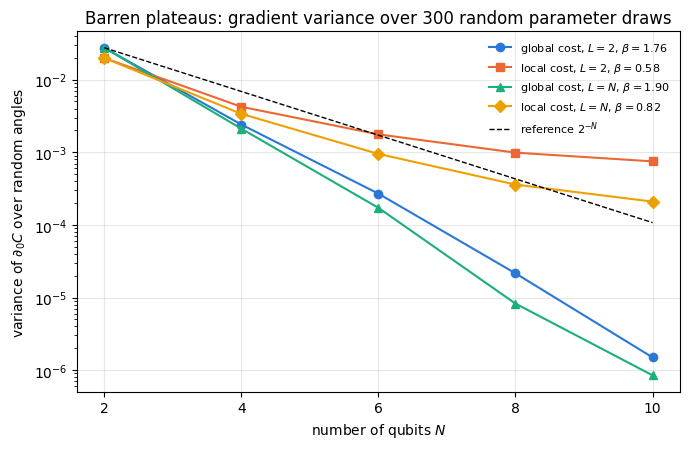

In [17]:
# ==============================================================================
# STEP 14: fit the exponent of Var ~ 2^{-beta N} and plot
# ==============================================================================
Ns = np.array(N_LIST, dtype=float)
labels = {"g2": r"global cost, $L=2$", "l2": r"local cost, $L=2$",
          "gN": r"global cost, $L=N$", "lN": r"local cost, $L=N$"}
fig, ax = plt.subplots(figsize=(7.0, 4.6))
print("least-squares fit of  log2 Var = alpha - beta N   (all N in the scan):")
print(f"{'cost':>22s} {'beta':>9s} {'Var(N=10)/Var(N=2)':>21s}")
plain = {"g2": "global, L=2", "l2": "local, L=2", "gN": "global, L=N", "lN": "local, L=N"}
for j, k in enumerate(("g2", "l2", "gN", "lN")):
    v = np.array(res[k])
    beta = -np.polyfit(Ns, np.log2(v), 1)[0]
    ax.semilogy(Ns, v, MARKERS[j] + "-", ms=6, color=PALETTE[j], label=f"{labels[k]}, $\\beta={beta:.2f}$")
    print(f"{plain[k]:>22s} {beta:9.3f} {v[-1] / v[0]:21.2e}")
ax.semilogy(Ns, res["g2"][0] * 2.0 ** (-(Ns - Ns[0])), "k--", lw=1, label=r"reference $2^{-N}$")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel(r"variance of $\partial_0 C$ over random angles")
ax.set_xticks(Ns)
ax.set_title(f"Barren plateaus: gradient variance over {R_DRAWS} random parameter draws")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**What the numbers say.** All four curves fall with $N$, but not at the same rate, and the fitted exponents $\beta$ of
$\mathrm{Var}\sim2^{-\beta N}$ separate them cleanly into two pairs.

* The two **global-cost** curves have $\beta\approx1.8$ ($L=2$) and $\beta\approx1.9$ ($L=N$) — steeper than the
  reference line $2^{-N}$, and *the shallow circuit is almost as bad as the deep one*. Over the measured range the
  variance drops by nearly five orders of magnitude from $N=2$ to $N=10$. This is the specific claim of Cerezo *et al.*:
  for an observable that acts on all $N$ qubits at once, the concentration sets in at depth $O(1)$, so the circuit's
  depth is not the culprit — the observable's *locality* is.
* The two **local-cost** curves have $\beta\approx0.6$ ($L=2$) and $\beta\approx0.8$ ($L=N$) — three times shallower at
  fixed depth, a factor of roughly $30$ in variance at $N=10$ between the local and the global cost of the *same*
  circuit at the *same* random angles. Increasing the depth from $L=2$ to $L=N$ pushes the circuit towards a 2-design
  and steepens the local decay noticeably, which is the depth effect that Cerezo *et al.* bound by requiring
  $O(\log N)$ depth.

The mean gradient component printed in the last column of the previous table is, within the sampling error of the draws,
zero at every $N$: the plateau is *flat*, not tilted. This is the harmful combination — no direction to descend, and a
signal that vanishes faster than the shot noise can be reduced.

### 13.3 What helps

Only claims this notebook demonstrates, or that are quoted with a reference:

* **Use a local cost.** Demonstrated above: at $L=2$ the local cost of Eq. (10) has a markedly smaller decay exponent
  than the global cost of Eq. (9), for exactly the same circuit and the same random angles. Both have the same minimiser
  (Section 5.3), so this costs nothing. (Cerezo *et al.*, 2021.)
* **Keep the circuit shallow.** Demonstrated above: for both costs the $L=N$ curve decays faster than the $L=2$ curve.
  Cerezo *et al.* prove that for local costs a depth $O(\log N)$ keeps the variance polynomial.
* **Use a problem-inspired ansatz.** Not measured here. The Hamiltonian-variational ansatz of Section 4.2 has $2L$
  parameters and a structure tied to the target, and therefore does not converge to a 2-design in the same way; the
  published analyses of this class are in Cerezo *et al.* (2021, *Nature Reviews Physics*).
* **Initialise with structure rather than uniformly.** Not measured here. The variance above was taken over the
  *uniform* distribution on $[-\pi,\pi]^n$, which is precisely the assumption of the theorem. Initialisations that start
  near the identity, or that grow the circuit layer by layer, sample a different distribution; this is reviewed in
  Cerezo *et al.* (2021, *Nature Reviews Physics*).

> **Common pitfall.** A barren plateau cannot be fixed by a better optimiser. Every method in this notebook — exact
> gradients included — needs to resolve $\partial_kC$ above the noise floor, and an exponentially small quantity
> requires exponentially many shots no matter how it is estimated. The remedy has to change the *cost* or the *ansatz*.

## 14. Key takeaways

* **A variational quantum algorithm is a hybrid loop**: a parametrized circuit prepares $\vert\psi(\boldsymbol\theta)
  \rangle$, a measurement returns a cost, a classical optimiser proposes new angles. The quantum part is deliberately
  short, which is why the framework targets present-day noisy hardware.
* **Parametrized gates are Pauli exponentials.** $P^2=\mathbb 1$ collapses the exponential series to
  $\cos\tfrac\theta2\,\mathbb 1-i\sin\tfrac\theta2\,P$, Eq. (2), for one-qubit and two-qubit Pauli rotations alike. A
  controlled rotation is also an exponential, but of a generator with eigenvalues $\{0,0,\pm\tfrac12\}$ — three distinct
  values — which is the whole reason it needs a different gradient rule.
* **Ansatz design is a choice between two philosophies.** Hardware-efficient: $2N(L+1)$ angles, native gates, no physics
  input, and (Section 13) exposure to barren plateaus. Hamiltonian-variational: $2L$ angles independent of $N$,
  descended from Trotterised adiabatic evolution, and guaranteed to contain a good state.
* **The cost along one angle is $a+b\cos(\theta-c)$, exactly.** The derivation is two projectors and a Hermiticity
  argument, Eq. (12); the three-parameter fit measured a residual at the $10^{-16}$ level.
* **Four gradients, measured.** Finite differences: error bottoming out at $6\cdot10^{-12}$ near $h_\star=10^{-5}$,
  where Eq. (16) puts it, and five orders of magnitude short of machine precision at every parameter count. Parameter
  shift: *exact*, $10^{-15}$ at every parameter count, $2n$ circuit evaluations, and a four-term generalisation,
  Eq. (19), that is needed — and verified — for controlled rotations, where the two-term rule is wrong by $0.2$.
  SPSA: unbiased and of variance $\lVert\nabla C\rVert^2-(\partial_kC)^2$ only in the small-$c$ limit, with both a
  visible $O(c^2)$ bias and a suppressed variance at $c=0.5$ and convergence onto the predictions by $c\le0.05$.
  Reverse-mode AD: machine precision, wall time set by the depth rather than the parameter count, and reproduced by a
  hand-written adjoint differentiator.
* **`vmap` is worth an order of magnitude here** — but it is not free. The identical parameter-shift formula runs ten to
  twenty times faster when the $2n$ shifted circuits are batched into one XLA program, and the measured scratch
  allocation is some seventy times that of a single forward pass, because eighty states are in flight at once.
* **Memory is the reverse-mode tax.** Storing intermediates costs $O(L\cdot2^N)$ — the measured scratch of `jax.grad`
  was about six times a forward pass; the adjoint trick, recomputing $\vert\psi_{l-1}\rangle=U_l^\dagger\vert\psi_l
  \rangle$ instead of storing it, brought it down to about twice a forward pass, which is the $O(2^N)$ it was designed
  for.
* **Shot noise costs $M^{-1/2}$ everywhere.** The parameter-shift estimator stays unbiased and its noise obeys
  Eq. (28); at equal shot budget, on this problem, the full parameter-shift gradient is more accurate than an SPSA
  sample, which saturates on its intrinsic $(n-1)\lVert\nabla C\rVert^2$ floor. SPSA's case has to be made at the level
  of the *optimisation*, not of the gradient estimate.
* **Barren plateaus are measurable.** The variance of one gradient component over random angles decays as
  $2^{-\beta N}$ with a fitted $\beta\approx1.8$ for the global cost and $\beta\approx0.6$ for the local cost of the
  *same shallow circuit* — the cost-locality effect of Cerezo *et al.*, measured rather than quoted, with a mean
  gradient consistent with zero throughout.

## 15. Exercises

1. ★ **Read the sinusoid.** For the circuit of Section 6, extract $a$, $b$ and $c$ from the fit and verify the two
   parameter-shift identities directly: $C(\theta+\tfrac\pi2)-C(\theta-\tfrac\pi2)=2C'(\theta)$, and
   $C(\theta+\pi)+C(\theta)=2a$. What does the second identity give you that the gradient does not?
2. ★ **The optimal finite-difference step in single precision.** Rerun Section 7 with `PRECISION = "single"` in the
   Configuration cell. Predict $h_\star$ and the achievable accuracy from Eq. (16) with
   $\varepsilon_{\text m}\approx1.2\cdot10^{-7}$ before you run it, then compare.
3. ★★ **A two-qubit rotation ansatz (extend the code).** Replace the fixed $CZ$ entanglers of the hardware-efficient
   ansatz by parametrized $R_{ZZ}(\theta)$ gates. Count the new parameters, check that the two-term parameter-shift rule
   still applies (what is the generator's spectrum?), and verify it against `jax.grad`.
4. ★★ **The four-term rule from scratch.** Derive the analogue of Eq. (19) for a generator whose eigenvalue gaps are
   $\{1,2\}$ (for instance $G=Z_1+Z_2$ with $\theta$ shared), and verify it numerically on a two-qubit circuit. How many
   evaluations per parameter does it need?
5. ★★ **SPSA variance with correlated directions (extend the code).** Replace the Rademacher $\boldsymbol\Delta$ by a
   Gaussian one. Show analytically that $\mathbb E[1/\Delta_k]$ no longer exists, measure what that does to the
   estimator's variance, and explain why Spall's condition on the perturbation distribution excludes the Gaussian.
6. ★★ **Cost of the adjoint method (extend the code).** Instrument `adjoint_gradient` to count gate applications, and
   verify the $\approx3L$ prediction of Section 10.1. Then compare its wall time with `jax.grad` across
   $N=4,6,8,10,12$ and comment on which one XLA optimises better.
7. ★★★ **Barren plateaus with a problem-inspired ansatz (physics).** Repeat the scan of Section 13 with the
   Hamiltonian-variational ansatz of Section 4.2 (note: $n=2L$, so choose $L$ to keep the comparison fair) and the TFIM
   energy as the cost. Does the gradient variance decay exponentially in $N$? At which depth does the behaviour change?
8. ★★★ **The shot budget that a plateau demands (physics).** Combine Sections 12 and 13: for the global cost at
   $L=2$, estimate from the fitted $\beta$ how many shots per circuit are needed for the parameter-shift gradient's
   standard deviation, Eq. (28), to fall below the typical gradient magnitude $\sqrt{\mathrm{Var}[\partial_kC]}$, and
   plot that budget against $N$. At which $N$ does it exceed the number of shots a real machine can take in a day?

## References

* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first
  variational quantum algorithm experiment.
* J. R. McClean, J. Romero, R. Babbush and A. Aspuru-Guzik, *The theory of variational hybrid quantum-classical
  algorithms*, New J. Phys. **18**, 023023 (2016) — the general framework of the hybrid loop of Section 1.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the
  hardware-efficient ansatz of Section 4.1.
* K. Mitarai, M. Negoro, M. Kitagawa and K. Fujii, *Quantum circuit learning*, Phys. Rev. A **98**, 032309 (2018) —
  the parameter-shift rule for Pauli-generated gates.
* M. Schuld, V. Bergholm, C. Gogolin, J. Izaac and N. Killoran, *Evaluating analytic gradients on quantum hardware*,
  Phys. Rev. A **99**, 032331 (2019) — the systematic treatment of Eq. (17) and its extensions.
* D. Wierichs, J. Izaac, C. Wang and C. Y.-Y. Lin, *General parameter-shift rules for quantum gradients*,
  Quantum **6**, 677 (2022) — the general rule for generators with several eigenvalue gaps, and the four-term rule of
  Eq. (19).
* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — SPSA, its unbiasedness and its convergence theory.
* T. Jones and J. Gacon, *Efficient calculation of gradients in classical simulations of variational quantum
  algorithms*, arXiv:2009.02823 (2020) — the adjoint-differentiation method of Section 10.2.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — the exponential concentration of Section 13.1.
* M. Cerezo, A. Sone, T. Volkoff, L. Cincio and P. J. Coles, *Cost function dependent barren plateaus in shallow
  parametrized quantum circuits*, Nat. Commun. **12**, 1791 (2021) — global versus local cost functions.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review of the
  whole field, including ansatz design and plateau mitigation.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/